<a href="https://colab.research.google.com/github/FarrelAD/Intelecta-Cup-Data-Mining-2025/blob/main/notebooks/improved-notebook-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img src="https://intelectacup.com/favicon.ico" /> Intelecta Cup - Data Mining Competition 2025  

---

## Informasi Tim
**Nama Tim:** Cognivio

**Institusi:** Politeknik Negeri Malang

| No | Anggota         | Peran                      |
|----|----------------------|----------------------------|
| 1  | Vidi Joshubzky Saviola    | Model Developer   |
| 2  | Cakra Wangsa May Ahmad Widodo             | ML Researcher              |
| 3  | Farrel Augusta Dinata             | ML Researcher Lead              |
| 4  | Hidayat Widi Saputra             | Model Developer   |

---

<div style="text-align:center; font-style:italic; opacity:0.8;">
  © 2025 Cognivio Team. All rights reserved.
</div>

# 0. Preparation

In [1]:
import os
import sys
import random
from itertools import combinations
from pathlib import Path
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries
from darts.models import (
    LightGBMModel,
    XGBModel,
    RegressionEnsembleModel,
    NaiveDrift,
    NaiveSeasonal,
)
from darts.dataprocessing.transformers import Scaler
from darts.utils.statistics import plot_residuals_analysis
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sklearn
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    TimeSeriesSplit
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    RandomForestClassifier
)
from sklearn.metrics import (
    make_scorer,
    mean_absolute_percentage_error,
    root_mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost
from xgboost import XGBRegressor
import lightgbm
from lightgbm import LGBMRegressor
from IPython.display import display
from typing import Literal, Union, Tuple, Literal


import warnings
warnings.filterwarnings('ignore')

# Detect environment
def detect_environment() -> str:
    """Detect if running in Colab, Kaggle, or local environment"""
    if 'google.colab' in sys.modules:
        return 'colab'
    elif 'kaggle_secrets' in sys.modules or os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    else:
        return 'local'

ENV = detect_environment()
print(f'🔍 Detected environment: {ENV.upper()}')


print(f'Python version: {sys.version}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')
print(f'Scikit-learn version: {sklearn.__version__}')
print(f'XGBoost version: {xgboost.__version__}')
print(f'LightGBM version: {lightgbm.__version__}')

🔍 Detected environment: COLAB
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1
XGBoost version: 3.1.1
LightGBM version: 4.6.0


# 1. Data Collection

In [2]:
def setup_dataset_paths(env: str) -> dict[str, str]:
    """Setup dataset paths based on environment"""

    # Kaggle environment
    if env == 'kaggle':
        return {
            'train_csv': "/kaggle/input/intelecta-cup-data-mining-competition/train.csv",
            'test_csv': "/kaggle/input/intelecta-cup-data-mining-competition/test.csv",
            'save_dir': "/kaggle/working"
        }

    # Local environment
    if env == 'local':
        base_path = "../data" # TODO: Adjust your local environment path
        return {
            'train_csv': f"{base_path}/train.csv",
            'test_csv': f"{base_path}/test.csv",
            'save_dir': f"{base_path}/models"
        }

    # Colab environment
    dataset_name = "intelecta-cup-data-mining-competition"
    local_path = "/content/dataset"

    # Check if dataset already exists
    if os.path.exists(local_path):
        return {
            'train_csv': f"{local_path}/train.csv",
            'test_csv': f"{local_path}/test.csv",
            'save_dir': "/content/drive/MyDrive/PROJECTS/Cognivio/models"
        }

    print("📥 Setting up tabular dataset in Colab...")

    # Setup Kaggle credentials
    _setup_kaggle_credentials()

    # Download and extract dataset
    _download_and_extract_dataset(dataset_name, local_path)

    return {
        'train_csv': f"{local_path}/train.csv",
        'test_csv': f"{local_path}/test.csv",
        'save_dir': "/content/drive/MyDrive/PROJECTS/Cognivio/models"
    }

def _setup_kaggle_credentials() -> None:
    """Setup Kaggle credentials in Colab"""
    kaggle_json_drive = "/content/drive/MyDrive/kaggle.json"
    kaggle_json_local = "/root/.kaggle/kaggle.json"

    # Try to copy from Google Drive first
    if os.path.exists(kaggle_json_drive):
        print("📂 Copying kaggle.json from Drive...")
        !mkdir -p /root/.kaggle
        !cp "{kaggle_json_drive}" "{kaggle_json_local}"
        !chmod 600 "{kaggle_json_local}"
        print("✅ Kaggle credentials loaded from Drive")
        return

    # Fallback: manual upload
    print("⚠️ Please upload kaggle.json manually or place it in Drive root folder")
    from google.colab import files  # type: ignore
    uploaded = files.upload()

    for fn in uploaded.keys():
        !mkdir -p /root/.kaggle
        !mv "{fn}" "/root/.kaggle/kaggle.json"
        !chmod 600 "/root/.kaggle/kaggle.json"
        print(f"✅ Kaggle credentials uploaded: {fn}")


def _download_and_extract_dataset(
    dataset_name: str,
    local_path: str
) -> None:
    """Download and extract Kaggle competition dataset"""
    import zipfile

    # Download dataset
    !kaggle competitions download -c {dataset_name} -p /content

    # Extract dataset
    zip_path = f"/content/{dataset_name}.zip"
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Dataset zip not found: {zip_path}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_path)

    print(f"✅ Dataset extracted to {local_path}")

# Setup paths
paths = setup_dataset_paths(ENV)
print(f"📁 Dataset paths configured for {ENV}:")
for key, path in paths.items():
    exists = "✅" if os.path.exists(path) else "⚠️"
    print(f"   {key}: {path} {exists}")

# Create save directory
os.makedirs(paths['save_dir'], exist_ok=True)

# Set random seed for reproducibility
def set_seed(seed: int = 20) -> None:
    random.seed(seed)
    np.random.seed(seed)

RANDOM_SEED = 20
set_seed(seed=RANDOM_SEED)

📁 Dataset paths configured for colab:
   train_csv: /content/dataset/train.csv ✅
   test_csv: /content/dataset/test.csv ✅
   save_dir: /content/drive/MyDrive/PROJECTS/Cognivio/models ✅


---

# 2. Data Cleaning & Preprocessing

## 2.1 Load Data

In [3]:
df = pd.read_csv(paths['train_csv'])

display(df.head(20))
display(df.describe())
display(df.info())

,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
0,0,2015,USA,South,Soybeans,1658.71,13.36,2.620,10,74.41,38.97,2.64,46.07,Manajemen Air,20.43
1,1,2022,China,East,Wheat,1478.74,9.55,0.570,2,36.90,49.99,77.22,88.87,Rotasi Tanaman,-0.33
2,2,2000,India,'West Bengal',Fruits,1252.34,27.37,2.115,3,34.21,2.75,83.94,77.15,Pertanian Organik,12.97
3,3,2008,Nigeria,'North West',Sugarcane,209.89,16.16,4.158,5,91.74,36.80,37.50,73.59,Pertanian Organik,12.81
4,4,1991,Canada,Ontario,Vegetables,1086.67,3.71,2.430,0,14.72,7.22,28.72,41.90,Tanpa Adaptasi,4.22
5,5,1990,Australia,Queensland,Fruits,2265.29,2.33,2.030,4,79.39,48.80,3.30,77.63,Tanpa Adaptasi,14.70
6,6,2017,Russia,Northwestern,Rice,586.35,7.00,1.070,10,88.96,42.20,71.15,45.82,Tanaman Tahan Kekeringan,7.34
7,7,1995,China,Central,Vegetables,2281.25,24.21,2.907,1,27.44,23.94,13.96,50.97,Tanaman Tahan Kekeringan,16.97
8,8,2016,France,'Provence-Alpes-Cote d’Azur',NaN,792.07,10.31,3.420,1,51.51,4.60,75.99,94.94,Pertanian Organik,30.23
9,9,1991,Nigeria,'North West',Cotton,1746.26,25.28,2.772,7,39.09,9.33,90.96,59.65,Manajemen Air,20.30


,ID,Tahun,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Suhu_Rata_Rata_C
count,8000.00000,8000.000000,7821.000000,8000.000000,7800.000000,8000.000000,7819.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3999.50000,2007.032750,1615.503060,15.271184,2.238219,4.989750,55.394575,24.920015,49.706654,64.824446,15.206680
std,2309.54541,10.106035,807.932322,8.551214,0.996626,3.171814,26.034847,14.454507,28.674985,20.153617,11.490611
min,0.00000,1990.000000,200.170000,0.500000,0.450000,0.000000,10.010000,0.000000,0.030000,30.000000,-4.990000
25%,1999.75000,1998.000000,929.290000,7.860000,1.449000,2.000000,32.905000,12.550000,25.160000,47.115000,5.377500
50%,3999.50000,2007.000000,1614.790000,15.250000,2.170000,5.000000,55.340000,24.930000,49.270000,64.675000,15.140000
75%,5999.25000,2016.000000,2316.820000,22.820000,2.930000,8.000000,77.770000,37.382500,74.430000,82.302500,25.340000
max,7999.00000,2024.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,35.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              8000 non-null   int64  
 1   Tahun                           8000 non-null   int64  
 2   Nama_Negara                     8000 non-null   object 
 3   Wilayah                         8000 non-null   object 
 4   Jenis_Tanaman                   7781 non-null   object 
 5   Total_Curah_Hujan_mm            7821 non-null   float64
 6   Emisi_CO2_JT_Ton                8000 non-null   float64
 7   Hasil_Panen_Ton_per_HA          7800 non-null   float64
 8   Kejadian_Cuaca_Ekstrim          8000 non-null   int64  
 9   Akses_Irigasi                   7819 non-null   float64
 10  Penggunaan_Pestisida_KG_per_HA  8000 non-null   float64
 11  Penggunaan_Pupuk_KG_per_HA      8000 non-null   float64
 12  Indeks_Kesehatan_Tanah          80

None

## 2.2 Split Dataset for Each Country

Mengurutkan data time series

In [4]:
if df['Tahun'].is_monotonic_increasing == False or df['Tahun'].is_monotonic_decreasing == False:
    print('Dataset tidak terurut berdasarkan waktu (tahun)')
else:
    print('Dataset sudah terurut berdasarkan waktu (tahun)')

Dataset tidak terurut berdasarkan waktu (tahun)


Mengurutkan data berdasarkan **Tahun**, **Wilayah**, dan **Jenis_Tanaman**

In [5]:
df = df.sort_values(
    by=['Tahun', 'Nama_Negara', 'Wilayah', 'Jenis_Tanaman'],
)
df.head(60)

,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
4819,4819,1990,Argentina,Northeast,Coffee,1238.02,5.97,0.970,8,80.49,26.03,56.52,81.69,Tanpa Adaptasi,1.01
4612,4612,1990,Argentina,Northeast,Corn,2412.68,21.37,1.719,9,13.86,33.40,97.57,54.26,Manajemen Air,11.81
4824,4824,1990,Argentina,Northeast,Cotton,1282.89,21.74,0.837,4,46.43,42.33,45.91,71.53,Rotasi Tanaman,27.75
1035,1035,1990,Argentina,Northeast,Fruits,2187.52,14.57,3.740,8,24.94,1.11,92.01,87.66,Rotasi Tanaman,30.46
2414,2414,1990,Argentina,Northeast,Fruits,893.09,6.89,3.700,8,57.33,43.73,23.63,59.92,Tanaman Tahan Kekeringan,10.46
170,170,1990,Argentina,Northeast,Rice,790.69,27.16,1.899,6,59.14,37.87,9.89,67.62,Pertanian Organik,26.70
5438,5438,1990,Argentina,Northeast,Sugarcane,2874.40,22.56,4.221,0,96.19,24.62,68.72,78.90,Tanaman Tahan Kekeringan,15.02
7483,7483,1990,Argentina,Northeast,Vegetables,444.01,13.18,2.484,6,66.28,21.31,33.35,98.73,Rotasi Tanaman,6.79
5251,5251,1990,Argentina,Northeast,NaN,720.38,11.03,2.360,0,93.23,37.02,51.92,61.07,Rotasi Tanaman,10.91
2036,2036,1990,Argentina,Northwest,Coffee,2387.84,10.37,2.820,4,36.12,21.40,53.24,62.53,Rotasi Tanaman,11.93


Data splitting

In [6]:
# uncomment below if you want to export the sorted data to CSV file
# for country in df['Nama_Negara'].unique():
#     country_df = df[df['Nama_Negara'] == country]

#     country_df.to_csv(f'../outputs/{country}_sorted.csv', index=False)

## 2.3 Checking Correlation between Each Features

### 2.3.1 Numeric-numeric features

                                   Tahun  Total_Curah_Hujan_mm  \
Tahun                           1.000000              0.012556   
Total_Curah_Hujan_mm            0.012556              1.000000   
Emisi_CO2_JT_Ton               -0.005061             -0.007133   
Hasil_Panen_Ton_per_HA         -0.001188              0.023763   
Kejadian_Cuaca_Ekstrim          0.000736              0.004888   
Akses_Irigasi                  -0.007673             -0.013014   
Penggunaan_Pestisida_KG_per_HA -0.003620              0.004846   
Penggunaan_Pupuk_KG_per_HA      0.021150             -0.020502   
Indeks_Kesehatan_Tanah         -0.006140             -0.018602   
Suhu_Rata_Rata_C               -0.008861              0.008695   

                                Emisi_CO2_JT_Ton  Hasil_Panen_Ton_per_HA  \
Tahun                                  -0.005061               -0.001188   
Total_Curah_Hujan_mm                   -0.007133                0.023763   
Emisi_CO2_JT_Ton                        1.000

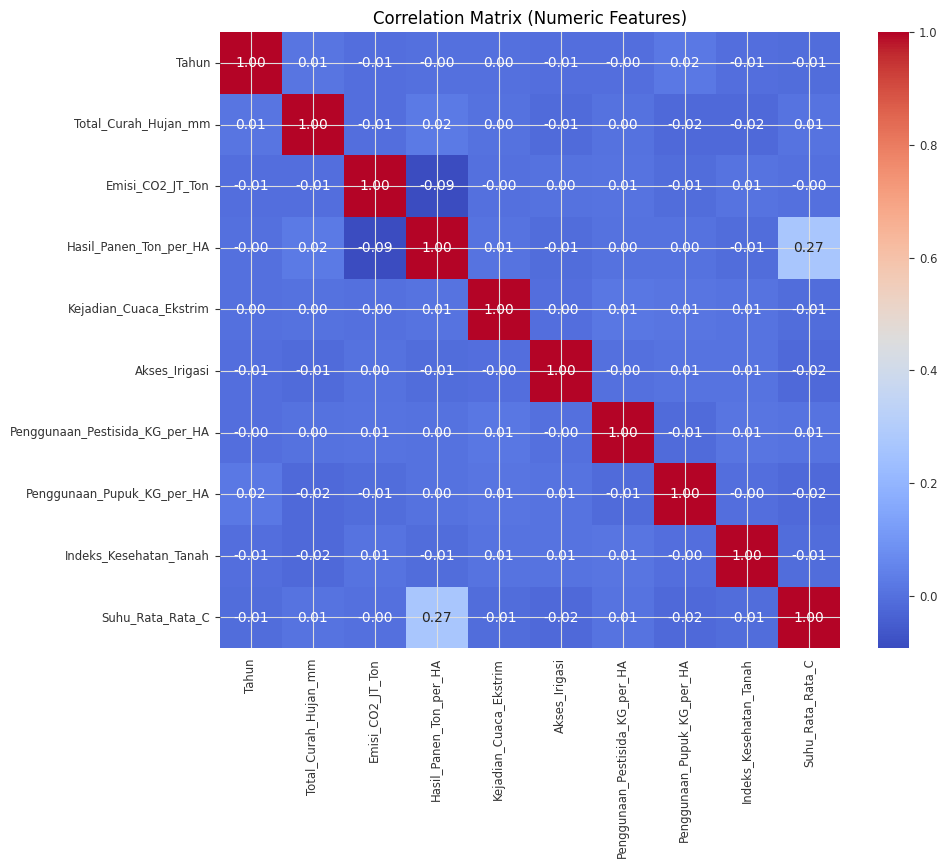

In [7]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['ID'])

# Compute correlation matrix
corr_matrix = numeric_df.corr(method='pearson')

# Display matrix
print(corr_matrix)

# Optional: visualize heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

### 2.3.2 Numeric-categorical features

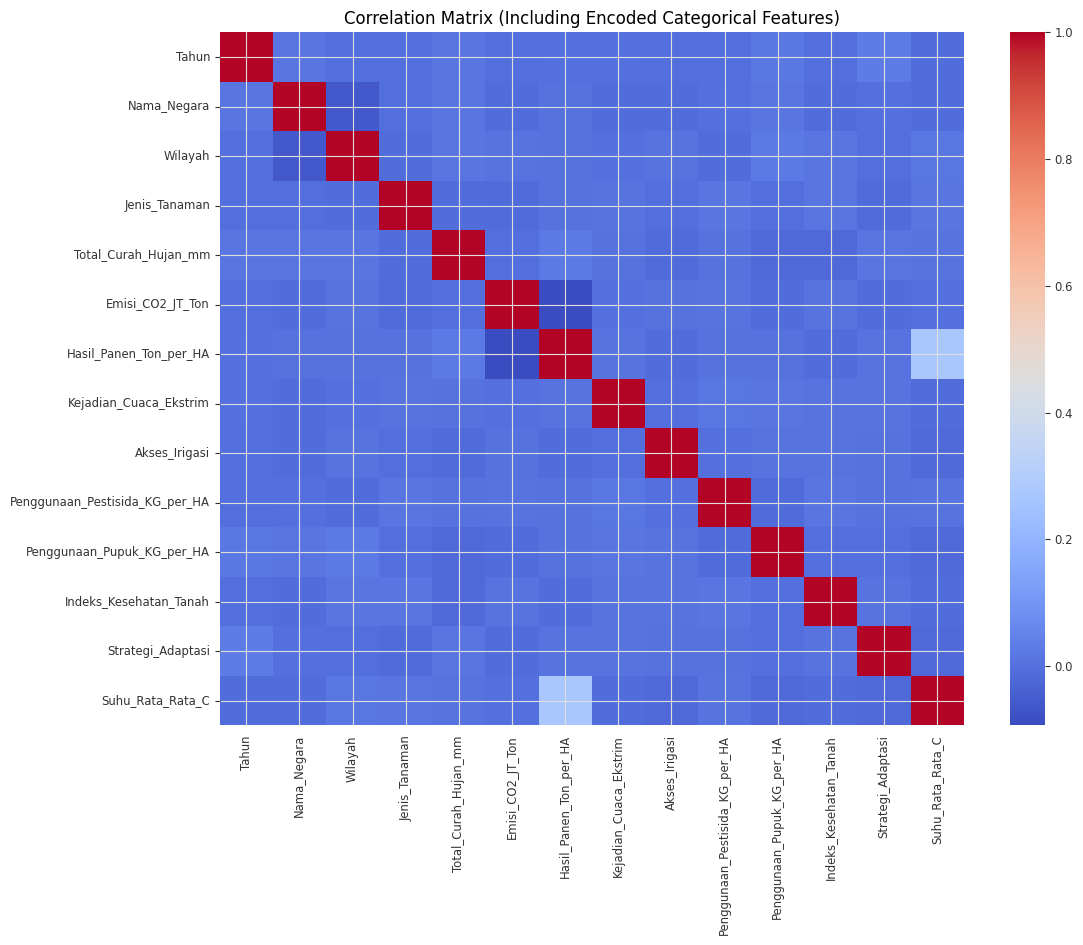

In [8]:
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['ID'])

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr_matrix = df_encoded.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix (Including Encoded Categorical Features)")
plt.show()

### 2.3.3 Linearity Correlation

#### Numeric features

Total paris: 45


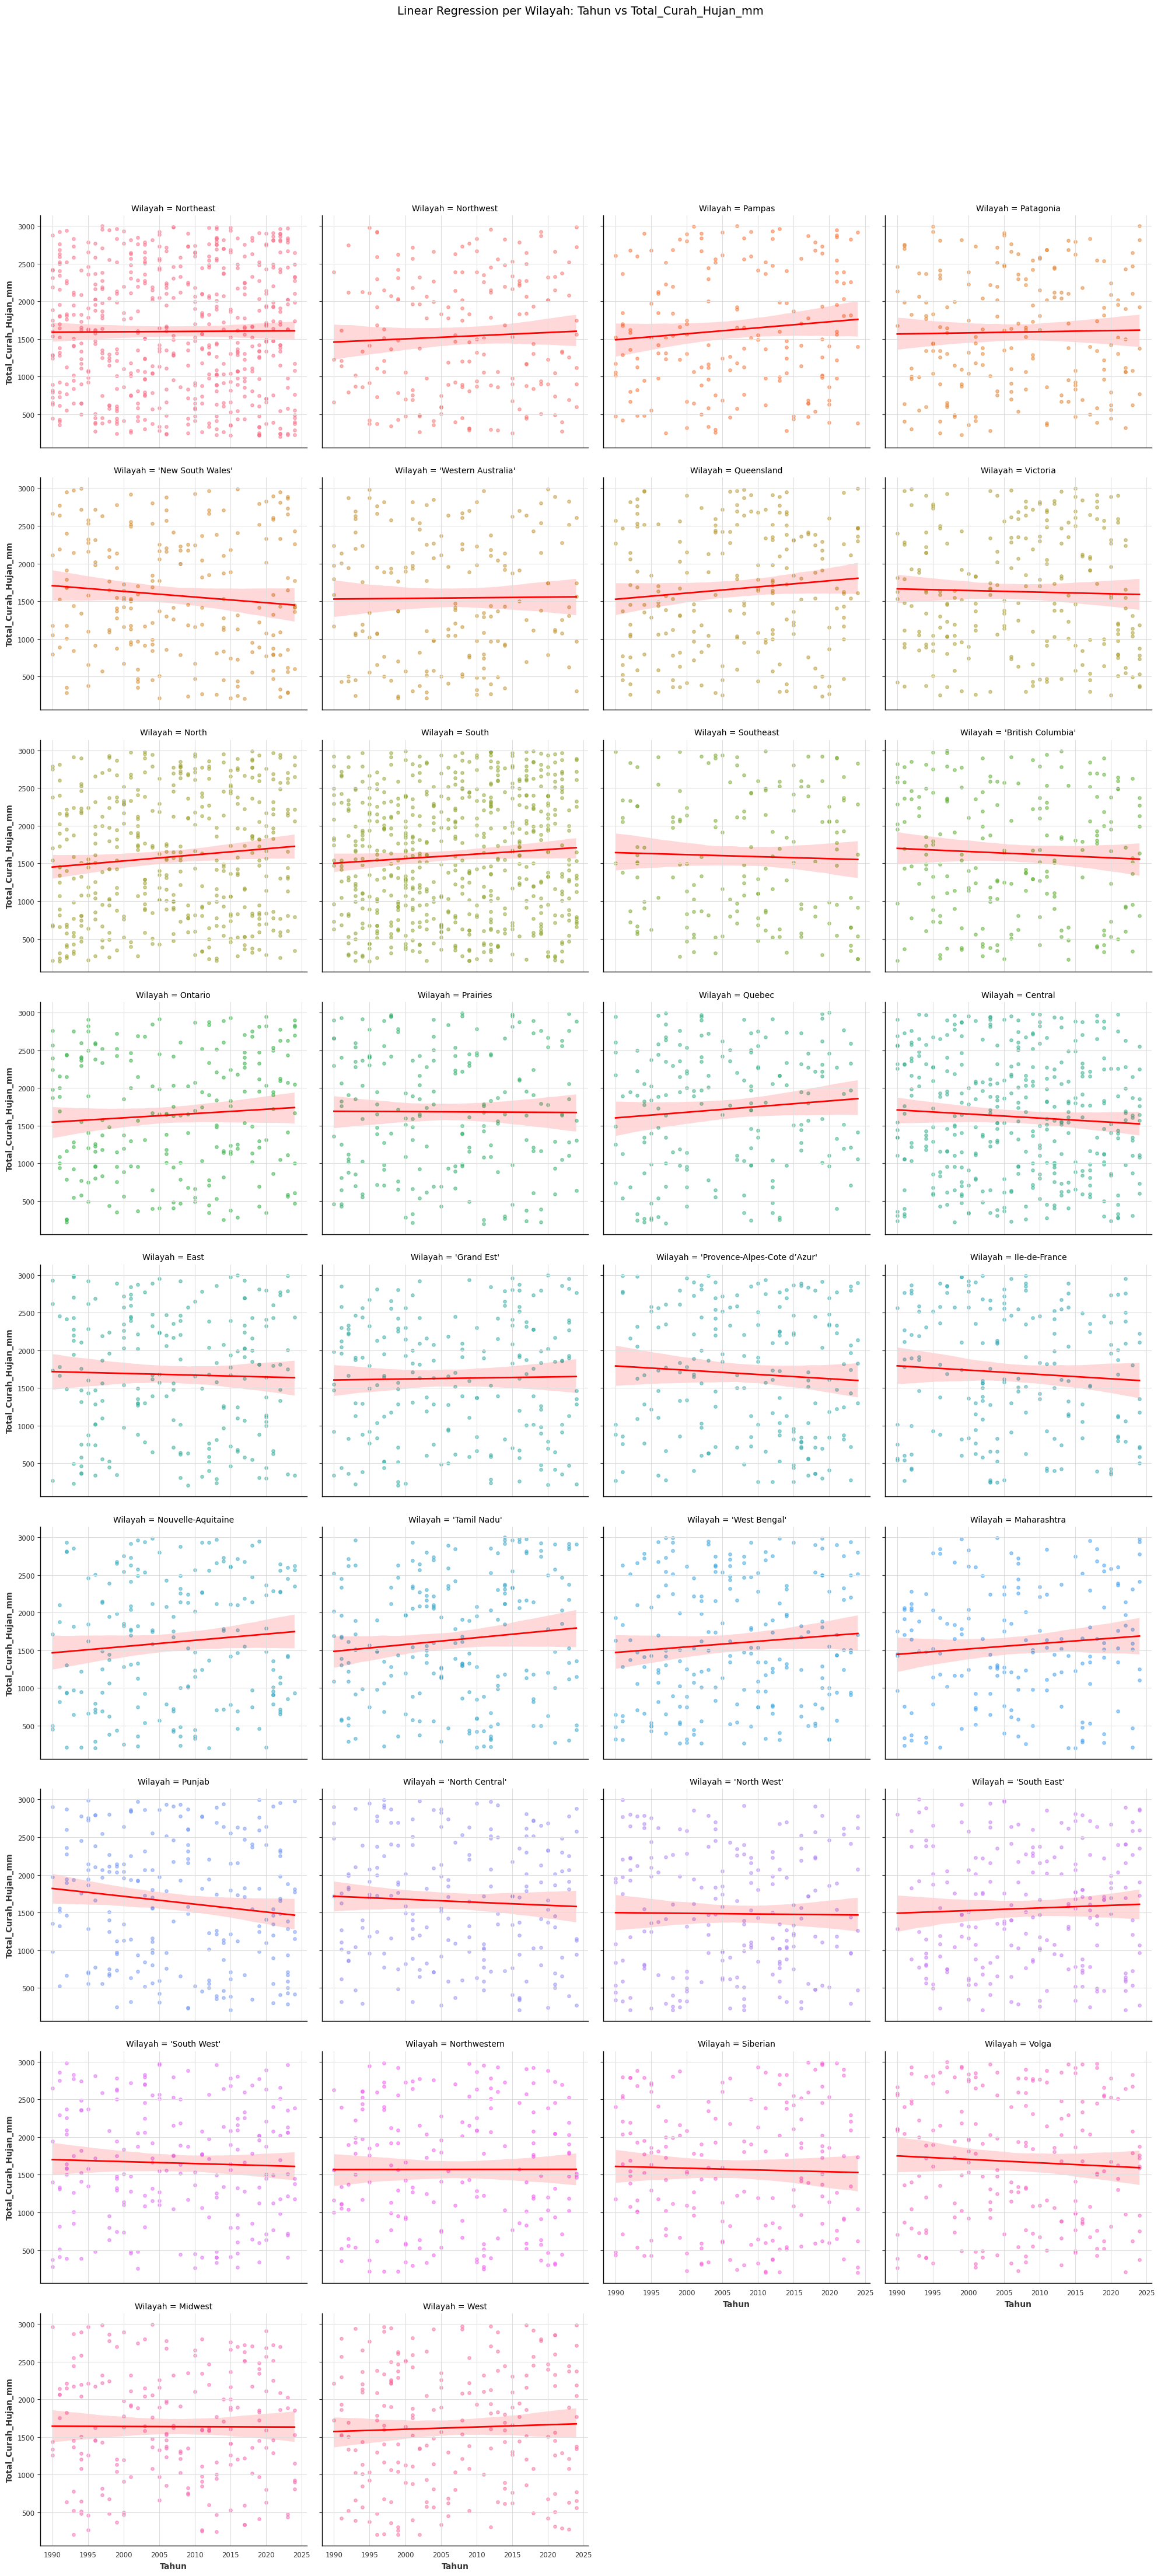

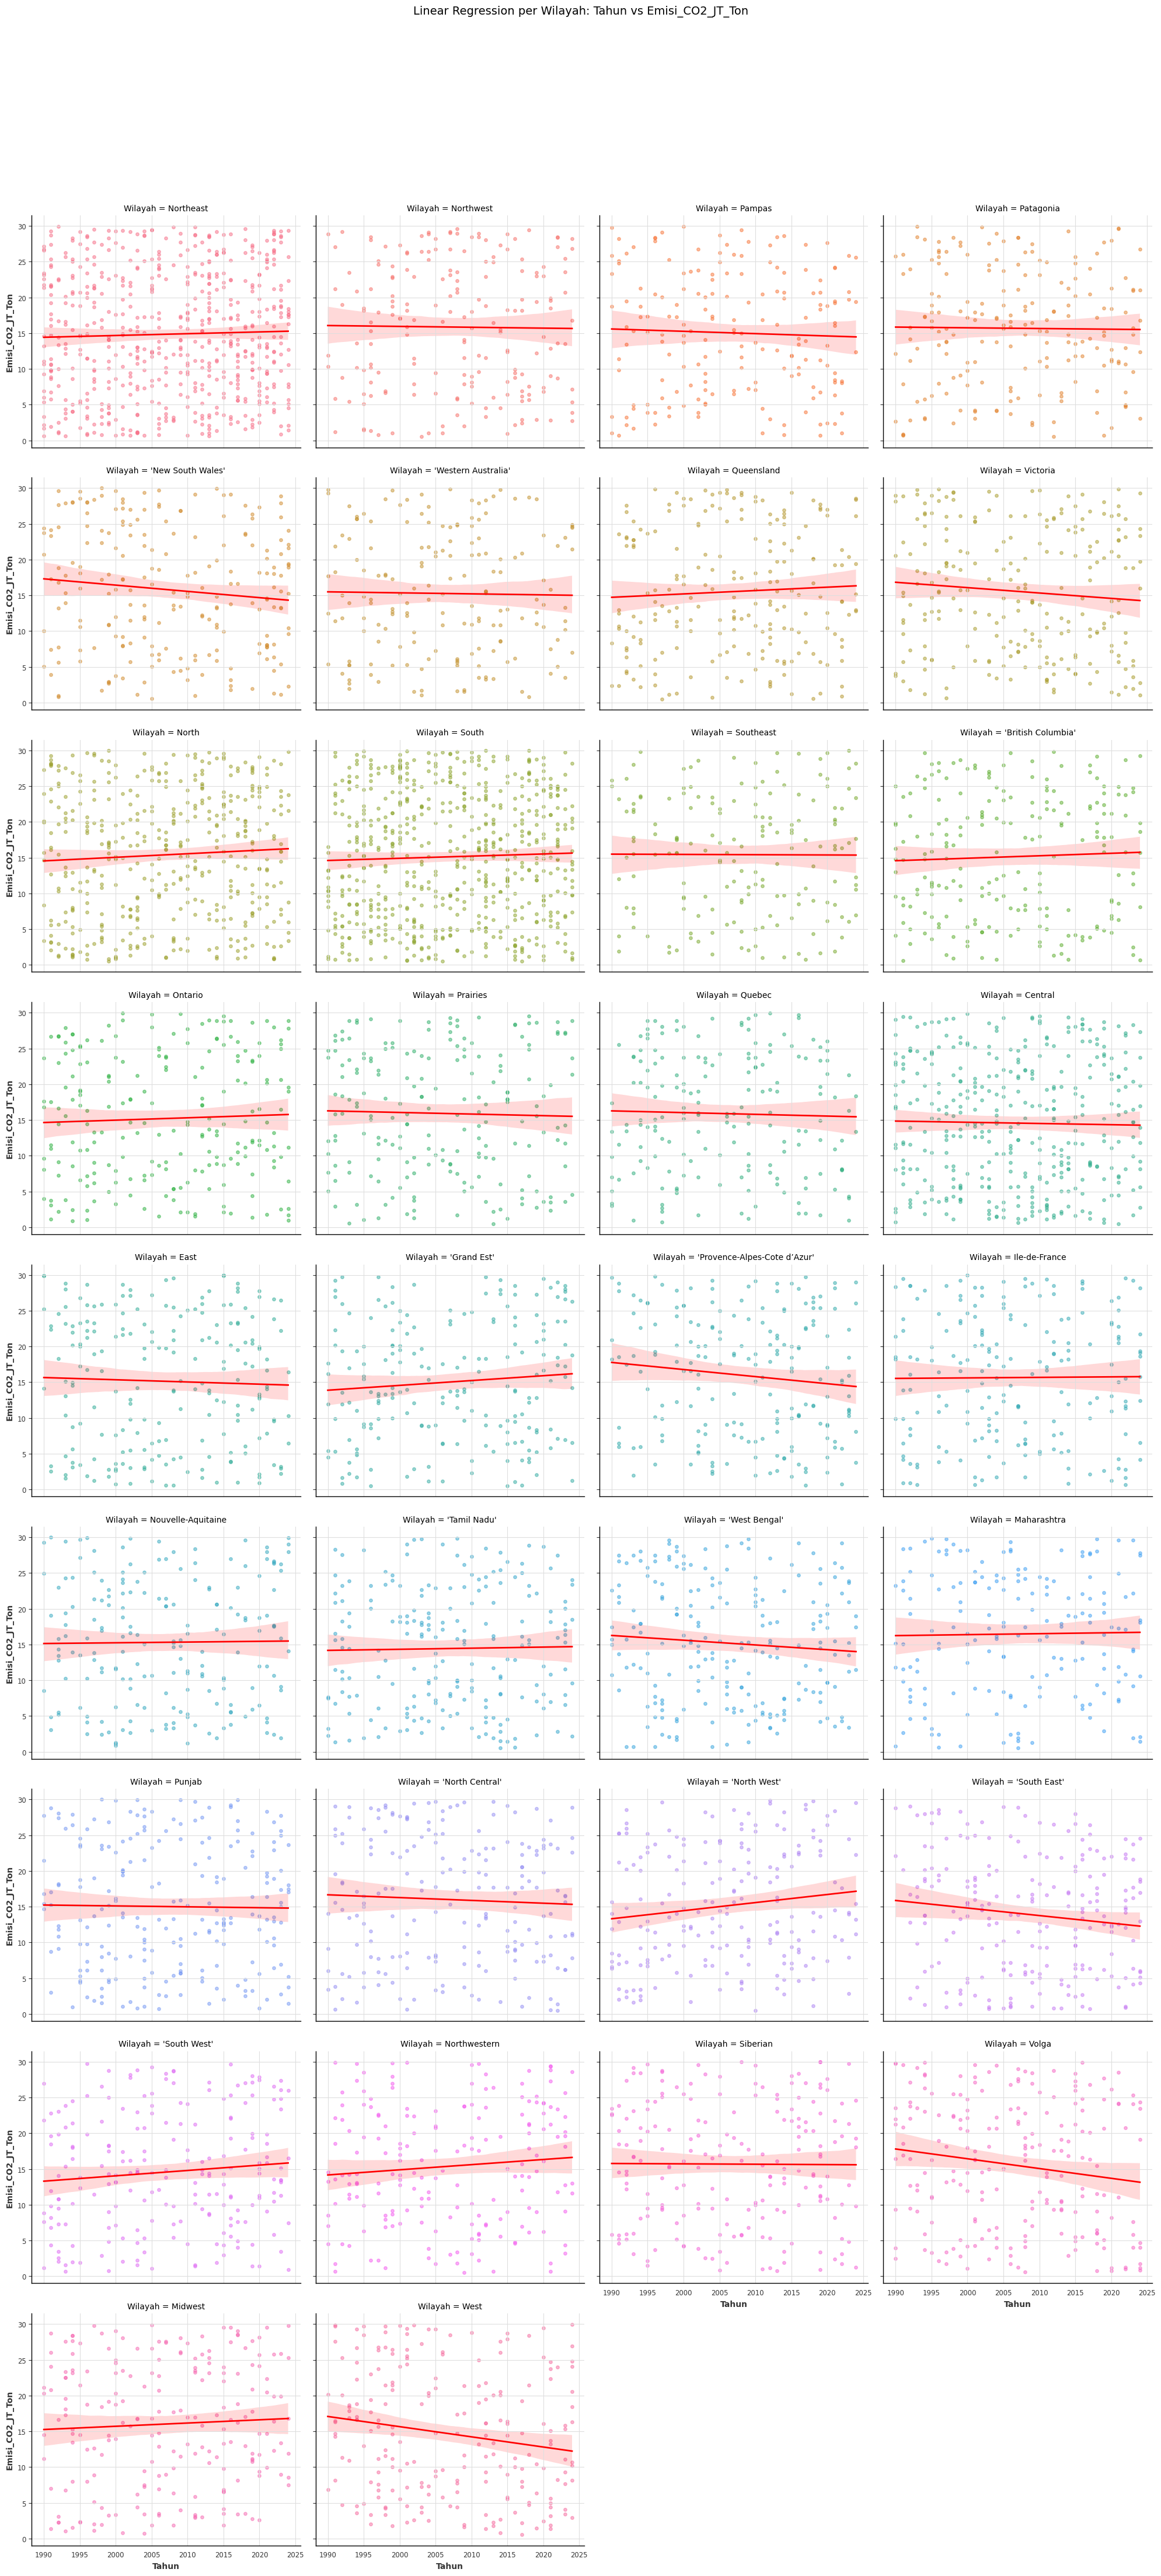

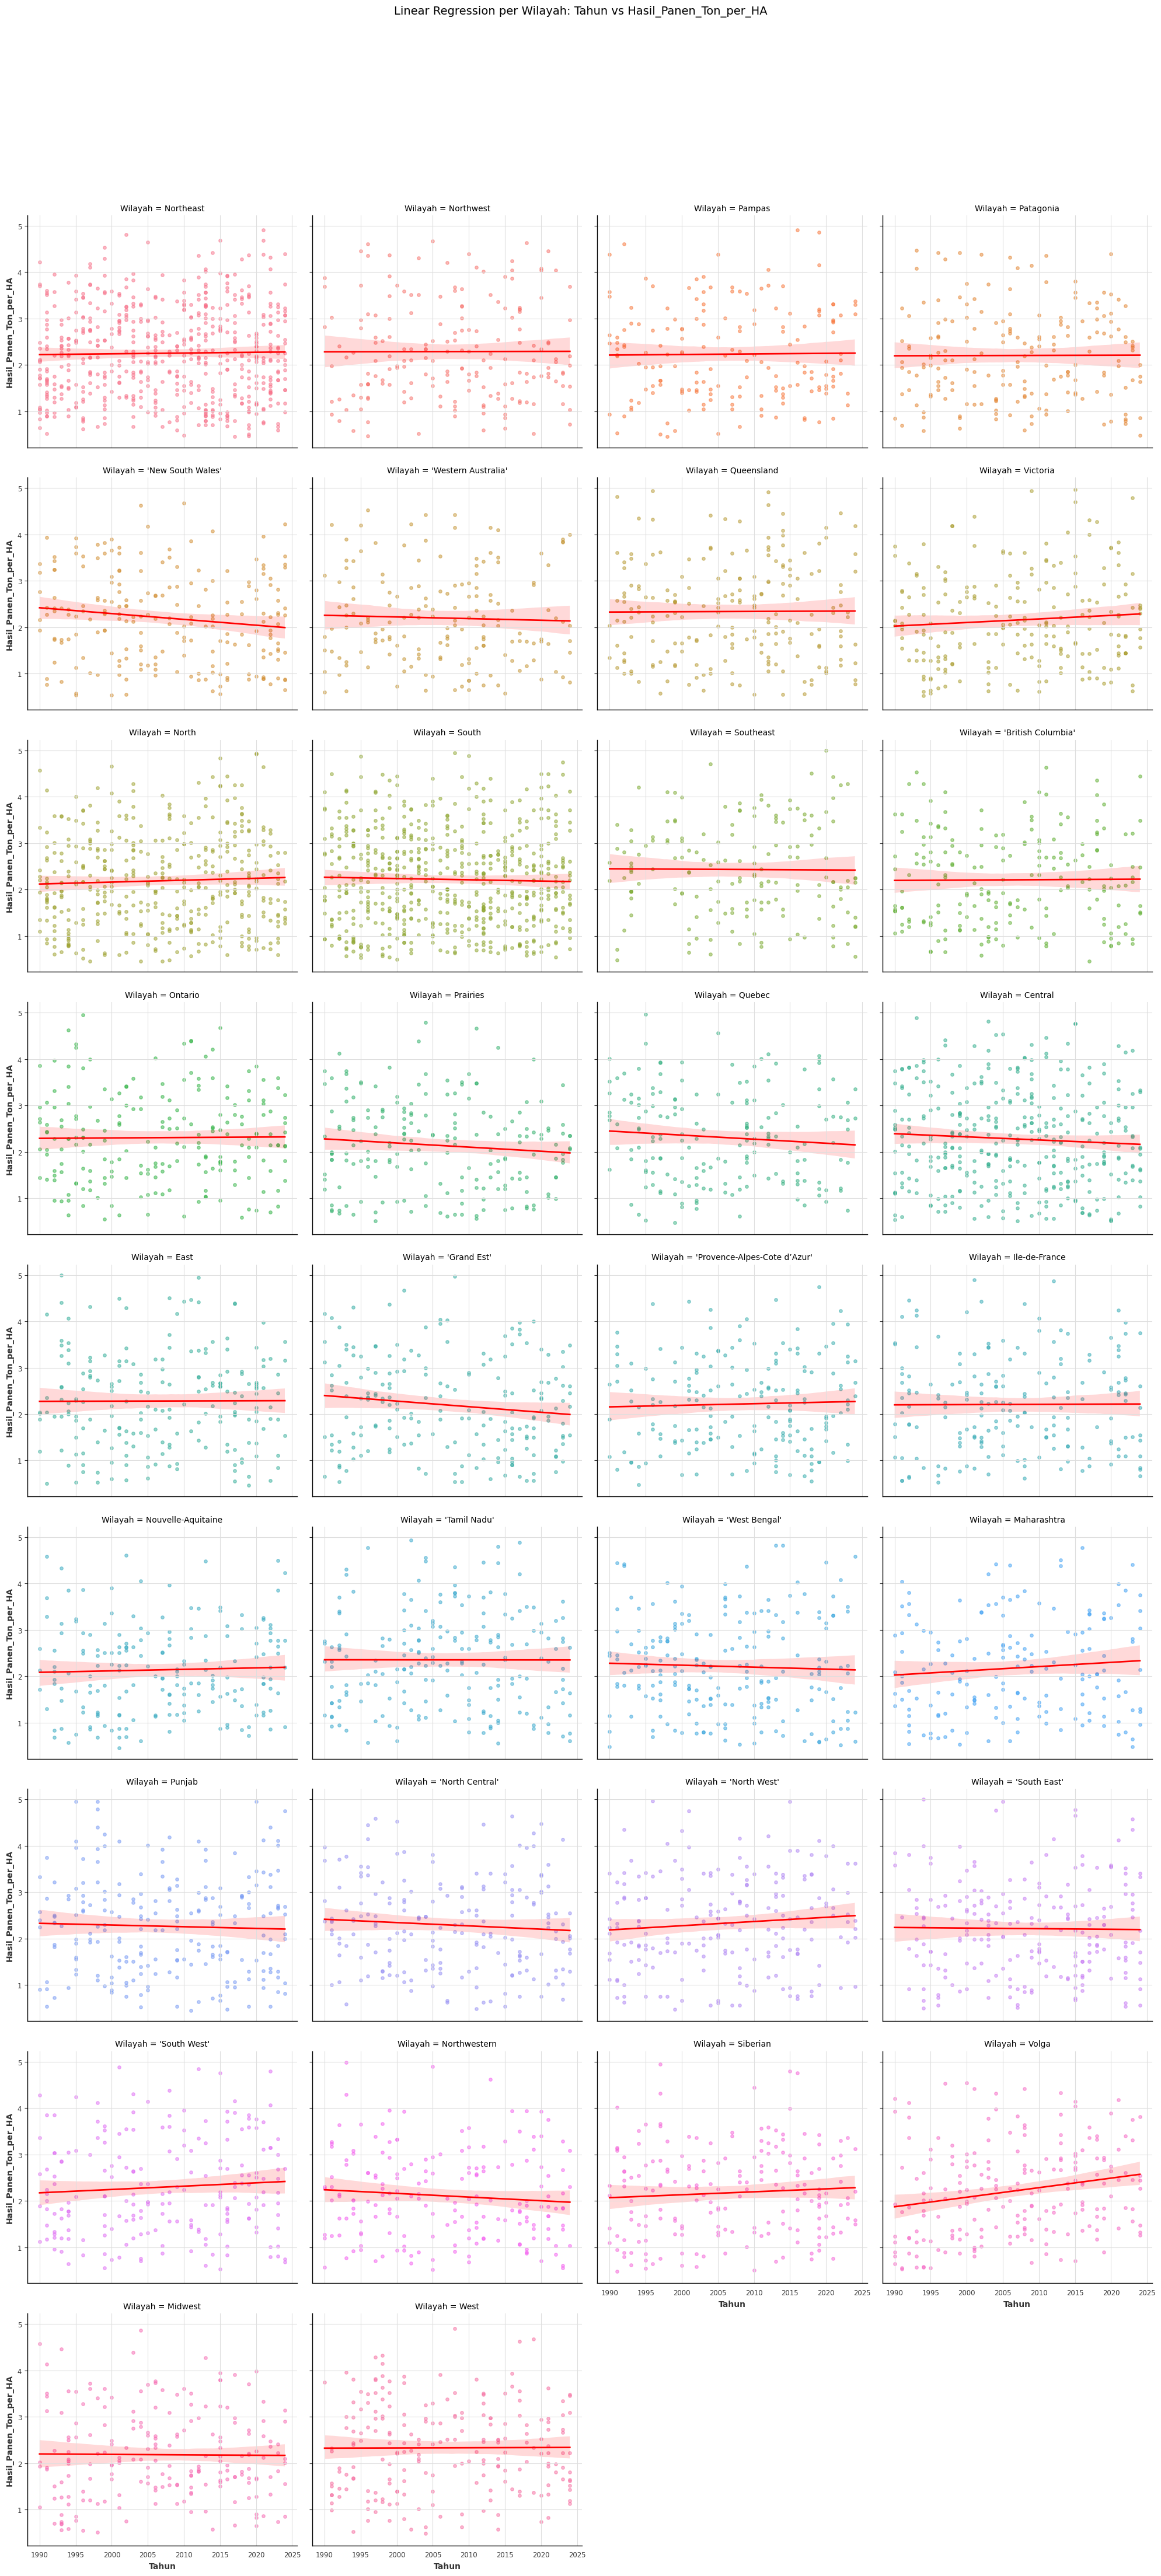

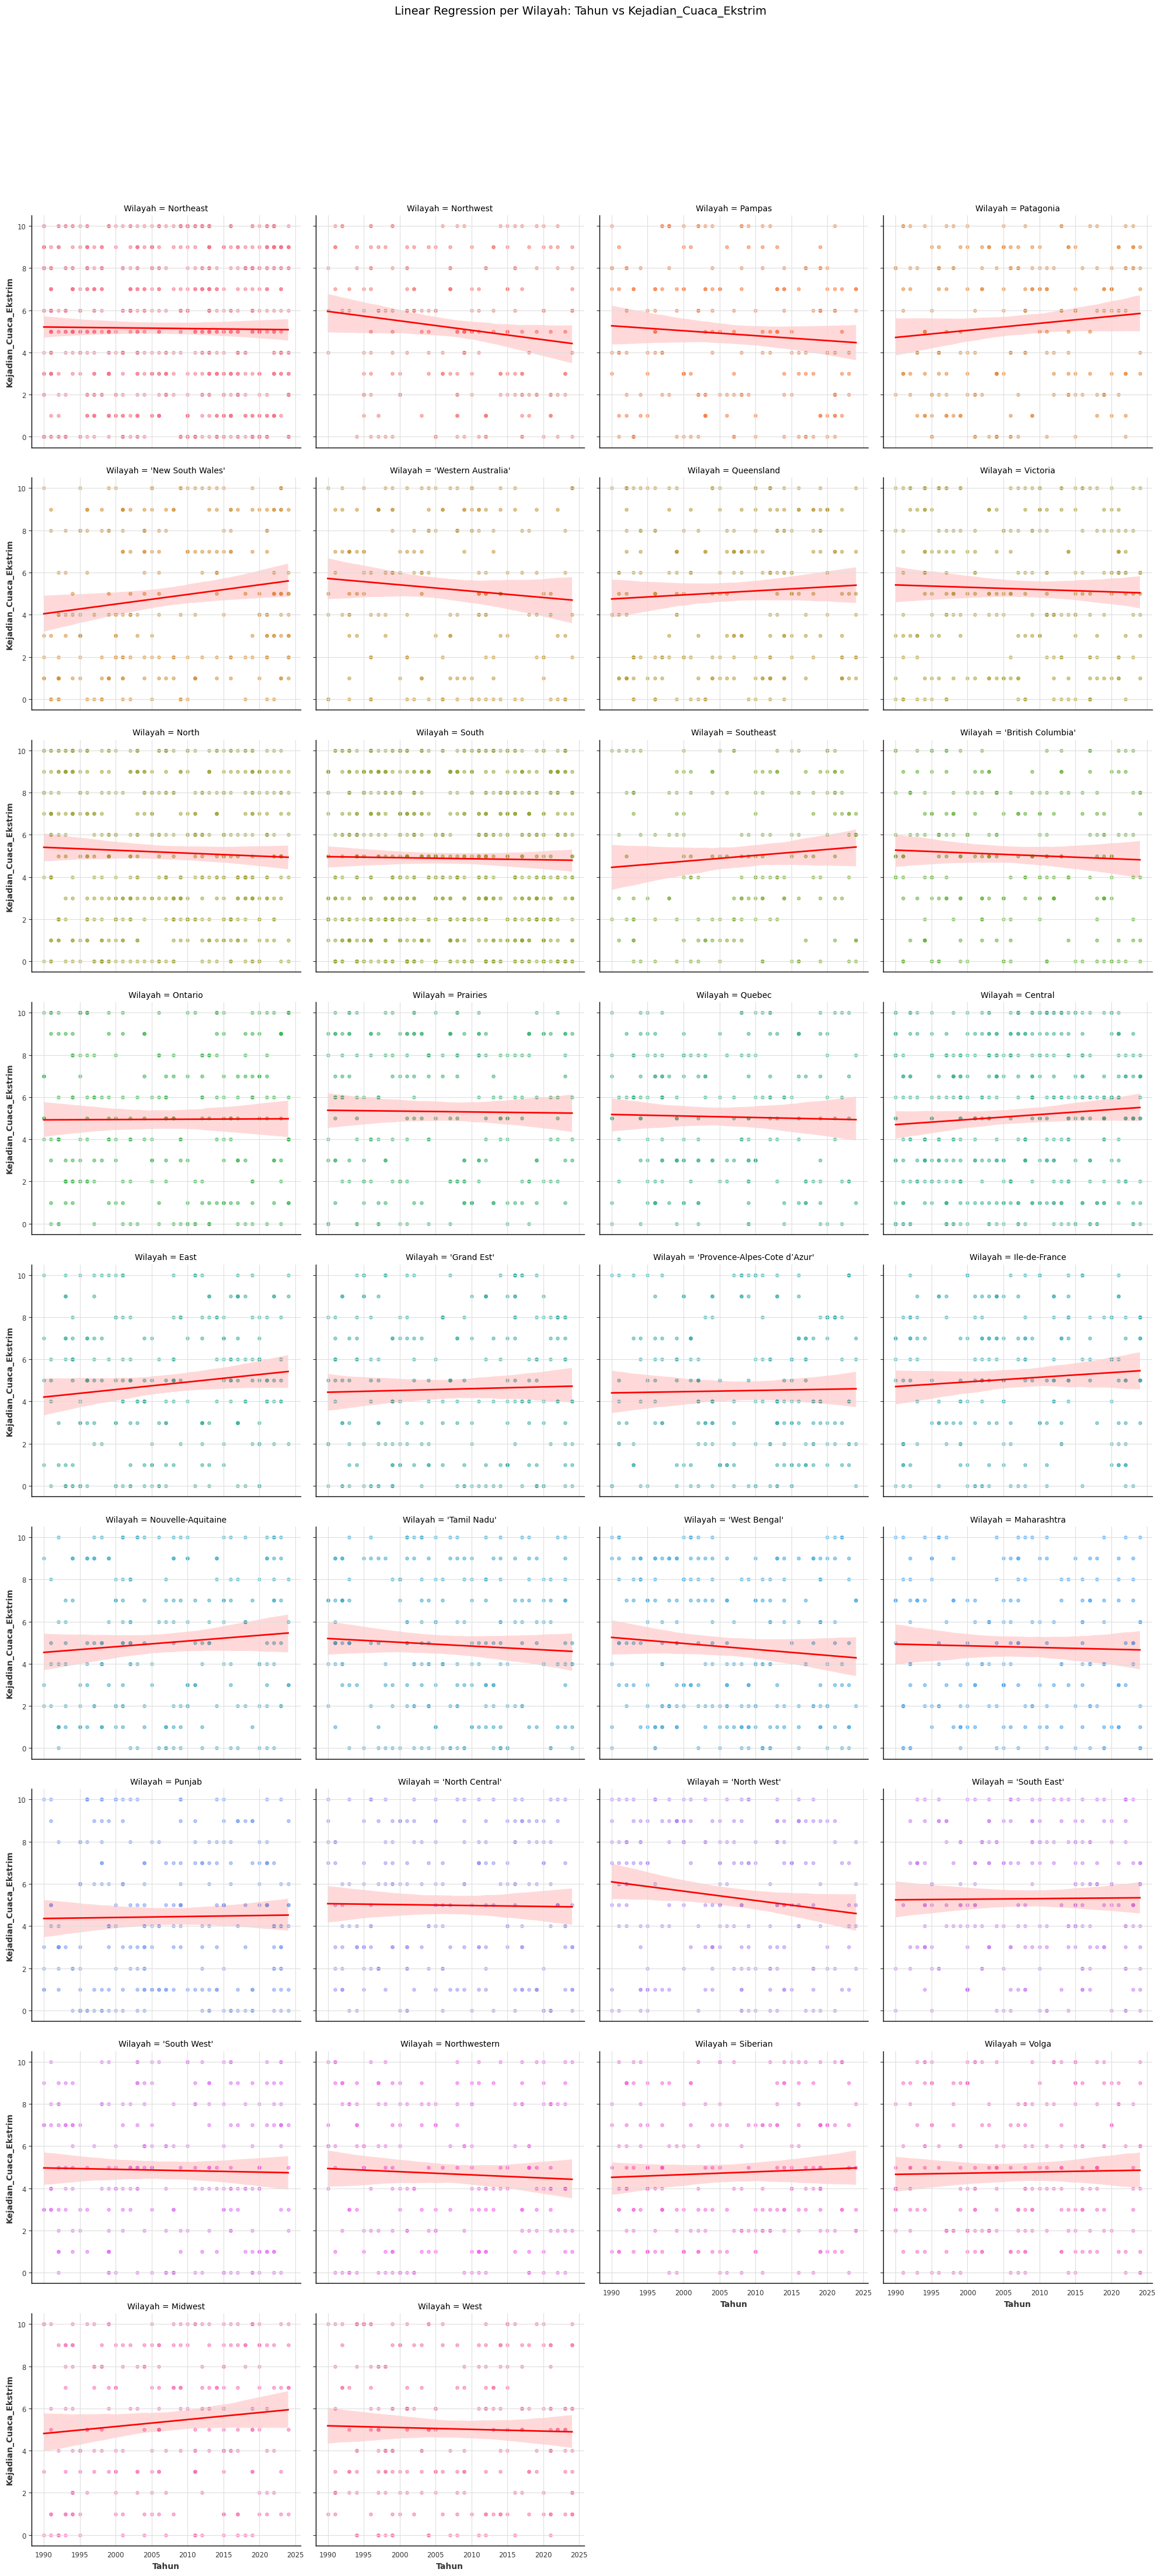

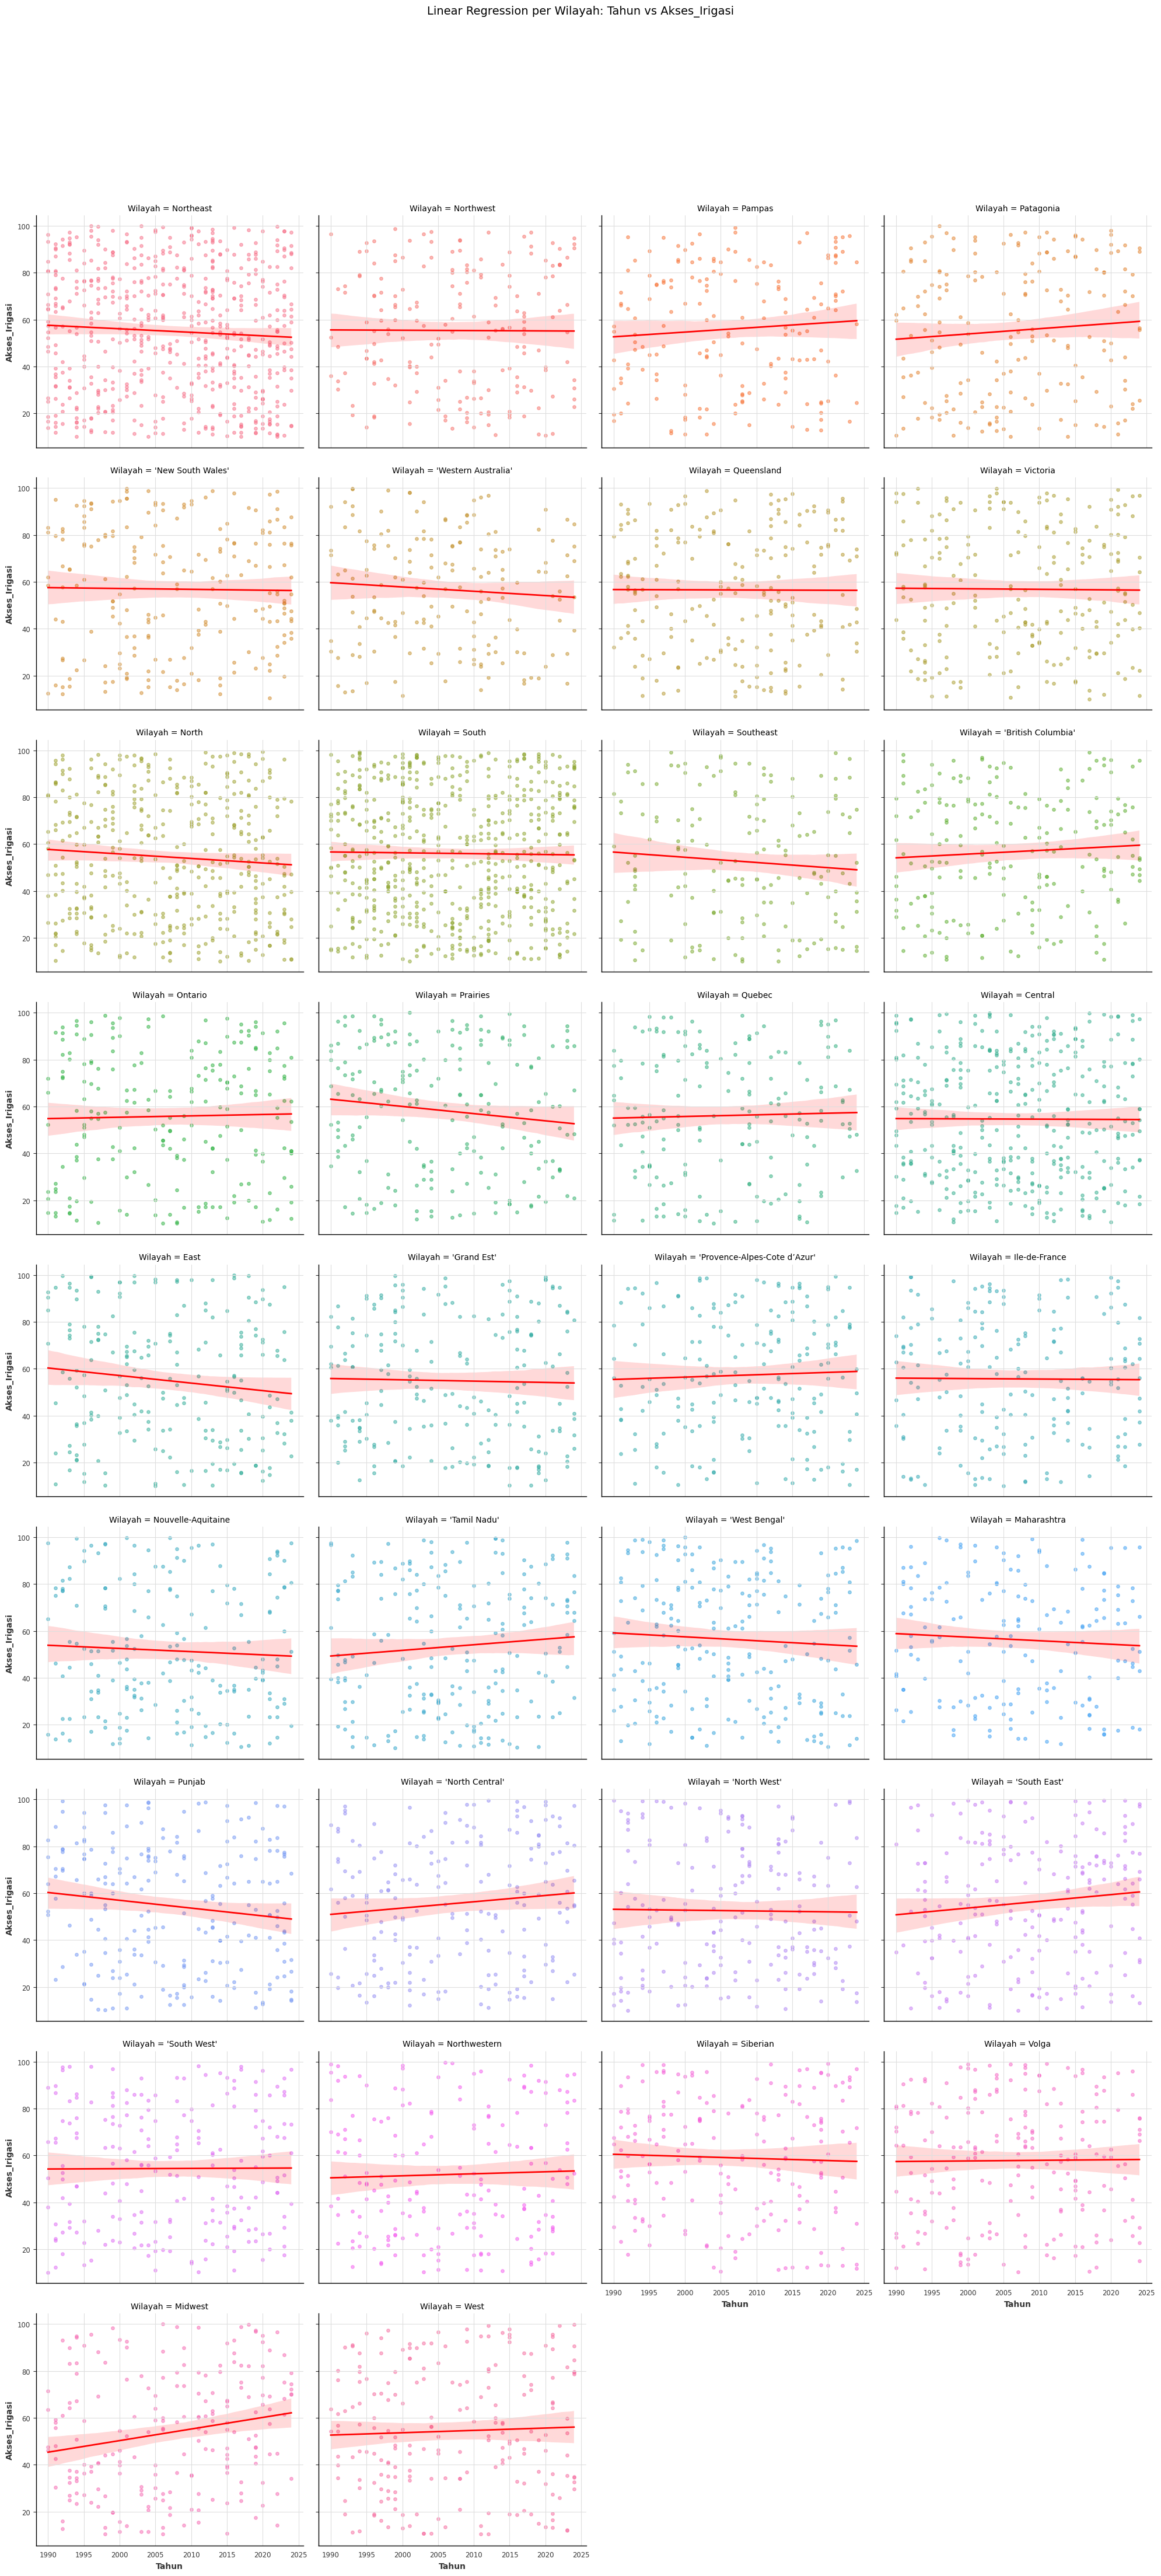

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('ID')
numeric_df = df[numeric_cols]

pairs = list(combinations(numeric_cols, 2))
print(f'Total paris: {len(pairs)}')

def plot_feature_correlations(
    df: pd.DataFrame,
    group_col: str = 'Wilayah',
    max_plots: int = 10
) -> None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('ID')
    pairs = list(combinations(numeric_cols, 2))

    for i, (x, y) in enumerate(pairs[:max_plots]):  # limit to first N pairs
        sns.lmplot(
            data=df,
            x=x,
            y=y,
            hue=group_col,
            col=group_col,
            col_wrap=4,
            scatter_kws={'alpha': 0.5, 's': 15},
            line_kws={'color': 'red'}
        )
        plt.subplots_adjust(top=0.9)
        plt.suptitle(f'Linear Regression per {group_col}: {x} vs {y}', fontsize=14)
        plt.show()

plot_feature_correlations(df, group_col='Wilayah', max_plots=5)

### 2.3.4 Temporal Dependency

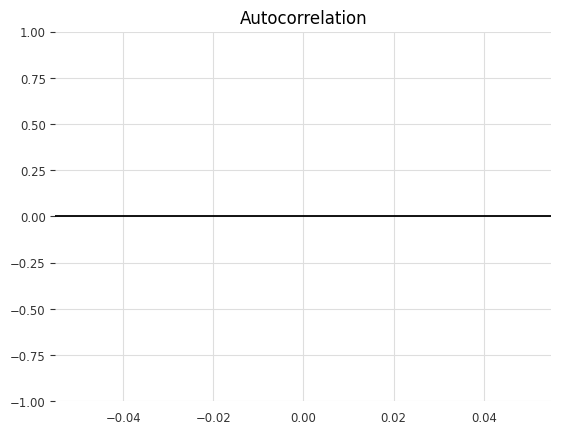

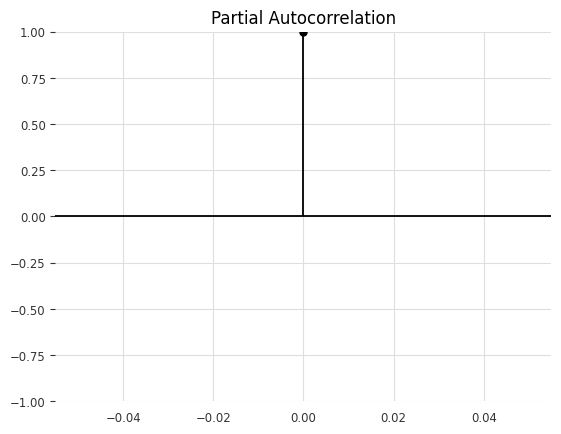

In [10]:
plot_acf(df['Akses_Irigasi'])
plot_pacf(df['Akses_Irigasi'])
plt.show()

## 2.4 Data Imputation Strategy

Data imputation adalah teknik yang digunakan untuk mengisi data-data kosong. Jika dilihat dari karakteristik tiap-tiap kolom, maka proses data imputation perlu dilakukan dengan teknik yang berbeda agar sesuai.

**Teknik-Teknik dalam Data Imputation:**

1. Statistical heuristic
2. Pendekatan machine learning

In [11]:
print(f'Total data kosong: {df.isnull().values.sum()}')
display(df.isnull().sum())

Total data kosong: 779


,0
ID,0
Tahun,0
Nama_Negara,0
Wilayah,0
Jenis_Tanaman,219
Total_Curah_Hujan_mm,179
Emisi_CO2_JT_Ton,0
Hasil_Panen_Ton_per_HA,200
Kejadian_Cuaca_Ekstrim,0
Akses_Irigasi,181


Pengecekan data yang null di tiap-tiap kolom

In [12]:
data_jenis_tanaman_null = df[df['Jenis_Tanaman'].isnull()]
print('Data jenis tanaman yang null')
display(data_jenis_tanaman_null)

data_total_curah_hujan_null = df[df['Total_Curah_Hujan_mm'].isnull()]
print('\nData total curah hujan yang null')
display(data_total_curah_hujan_null)

data_hasil_panen_null = df[df['Hasil_Panen_Ton_per_HA'].isnull()]
print('\nData hasil panen ton per HA yang null')
display(data_hasil_panen_null)

data_akses_irigasi_null = df[df['Akses_Irigasi'].isnull()]
print('\nData akses irigasi yang null')
display(data_akses_irigasi_null)

data_most_null = df[
    (df['Jenis_Tanaman'].isnull()) &
    (df['Total_Curah_Hujan_mm'].isnull()) &
    (df['Hasil_Panen_Ton_per_HA'].isnull()) &
    (df['Akses_Irigasi'].isnull())
]
print('\nData baris yang memiliki jenis tanaman, total curah hujan, hasil panen, dan akses irigas yang null')
display(data_most_null)

Data jenis tanaman yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
5251,5251,1990,Argentina,Northeast,NaN,720.38,11.03,2.360,0,93.23,37.02,51.92,61.07,Rotasi Tanaman,10.91
7342,7342,1990,Brazil,South,NaN,1539.58,9.70,1.760,2,49.92,12.68,10.67,96.86,Manajemen Air,16.81
2075,2075,1990,Canada,Quebec,NaN,2604.51,7.04,4.010,5,11.39,13.35,24.83,31.97,Pertanian Organik,16.89
7335,7335,1990,France,'Grand Est',NaN,1468.76,5.41,3.120,5,62.01,2.49,27.56,76.44,Tanaman Tahan Kekeringan,15.23
5453,5453,1991,Australia,'New South Wales',NaN,2189.72,24.16,2.430,9,79.66,7.56,60.74,74.22,Pertanian Organik,26.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,4243,2024,China,South,NaN,702.98,22.23,3.447,4,92.34,22.63,1.71,77.89,Tanpa Adaptasi,12.21
5725,5725,2024,India,Punjab,NaN,1241.33,18.00,0.810,4,14.62,28.22,10.06,77.37,Tanaman Tahan Kekeringan,-1.25
1678,1678,2024,Nigeria,'South East',NaN,1723.91,5.87,0.920,0,30.66,27.73,98.17,65.80,Rotasi Tanaman,24.81
4624,4624,2024,Russia,Volga,NaN,752.67,1.73,3.810,1,68.97,7.86,13.89,47.02,Manajemen Air,14.22



Data total curah hujan yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
2386,2386,1990,China,Central,Sugarcane,NaN,18.52,0.540,6,61.98,31.41,26.19,34.24,Tanpa Adaptasi,-1.20
336,336,1990,India,Punjab,Vegetables,NaN,16.80,0.900,1,63.89,33.77,94.56,51.92,Rotasi Tanaman,25.11
5728,5728,1991,Argentina,Northwest,Barley,NaN,21.20,1.206,9,73.23,3.75,65.62,74.45,Tanpa Adaptasi,23.06
2437,2437,1991,China,East,Fruits,NaN,22.40,2.358,4,45.42,17.63,88.66,63.44,Pertanian Organik,6.59
889,889,1991,France,Ile-de-France,Vegetables,NaN,4.18,2.990,2,14.00,18.05,56.55,74.26,Manajemen Air,28.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,418,2024,Australia,'New South Wales',Sugarcane,NaN,2.25,0.880,6,76.52,40.60,76.74,86.65,Pertanian Organik,2.42
7998,7998,2024,China,East,Barley,NaN,16.44,3.564,2,37.90,9.61,74.70,98.24,Tanaman Tahan Kekeringan,11.63
436,436,2024,France,Ile-de-France,Fruits,NaN,28.18,1.548,7,47.28,24.40,47.88,65.25,Rotasi Tanaman,18.20
822,822,2024,India,Maharashtra,Vegetables,NaN,27.44,1.242,1,NaN,45.99,13.61,91.13,Tanpa Adaptasi,27.37



Data hasil panen ton per HA yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
2112,2112,1990,Argentina,Patagonia,Cotton,2132.01,25.78,NaN,2,59.64,33.46,27.32,78.72,Tanpa Adaptasi,8.84
6200,6200,1990,Argentina,Patagonia,Soybeans,2455.56,2.62,NaN,8,10.60,16.11,4.05,84.43,Manajemen Air,3.54
792,792,1990,Brazil,Northeast,Corn,1684.51,0.64,NaN,3,26.68,6.68,19.94,98.57,Rotasi Tanaman,9.92
7636,7636,1990,Brazil,South,Rice,1741.26,0.86,NaN,9,66.27,46.73,77.48,62.54,Tanaman Tahan Kekeringan,19.73
7840,7840,1990,Russia,Central,Rice,1103.53,8.05,NaN,9,95.71,9.66,18.72,85.83,Tanpa Adaptasi,34.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6826,6826,2024,France,'Provence-Alpes-Cote d’Azur',Rice,2894.15,8.07,NaN,7,59.90,26.51,74.44,38.94,Tanaman Tahan Kekeringan,16.78
2238,2238,2024,Nigeria,'South East',Rice,1906.34,12.95,NaN,6,40.92,38.52,69.34,84.86,Tanaman Tahan Kekeringan,-2.55
3317,3317,2024,Nigeria,'South West',Soybeans,1181.35,7.45,NaN,7,61.16,39.40,53.95,91.52,Rotasi Tanaman,4.81
1972,1972,2024,Russia,Siberian,Cotton,1049.90,9.83,NaN,2,11.94,29.62,62.87,58.36,Rotasi Tanaman,14.89



Data akses irigasi yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
6425,6425,1990,France,Ile-de-France,Rice,2563.06,18.25,3.510,7,NaN,44.59,77.99,53.45,Tanpa Adaptasi,33.94
2595,2595,1990,Nigeria,'North Central',Coffee,2484.02,9.14,3.970,9,NaN,4.14,98.72,66.67,Tanpa Adaptasi,16.99
3811,3811,1990,Nigeria,'North West',Soybeans,1948.44,6.38,1.540,8,NaN,20.67,4.22,86.41,Tanpa Adaptasi,2.91
375,375,1991,Australia,'New South Wales',Rice,2772.50,7.45,3.940,3,NaN,29.25,37.98,60.56,Tanpa Adaptasi,16.86
1415,1415,1991,Australia,Victoria,NaN,1798.57,9.61,1.540,3,NaN,42.78,86.13,84.96,Manajemen Air,23.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4303,4303,2024,Australia,Queensland,Rice,1609.77,26.10,1.224,2,NaN,2.30,75.05,53.16,Manajemen Air,8.20
7984,7984,2024,India,Maharashtra,Soybeans,1251.00,27.80,3.042,10,NaN,48.70,15.88,57.10,Pertanian Organik,27.26
822,822,2024,India,Maharashtra,Vegetables,NaN,27.44,1.242,1,NaN,45.99,13.61,91.13,Tanpa Adaptasi,27.37
2221,2221,2024,India,Punjab,Coffee,NaN,3.72,4.760,6,NaN,42.62,75.25,37.44,Tanpa Adaptasi,14.89



Data baris yang memiliki jenis tanaman, total curah hujan, hasil panen, dan akses irigas yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C


### 2.4.1 Statistical Heuristic

#### **Jenis_Tanaman** Column

Diasumsikan bahwa **Jenis_Tanaman** memiliki korelasi dengan data **Penggunaan_Pupuk_KG_per_HA**, **Penggunaan_Pestisida_KG_per_HA**, dan juga **Hasil_Panen_Ton_per_HA**

In [13]:
df['Pupuk_bin'] = pd.qcut(df['Penggunaan_Pupuk_KG_per_HA'], q=5, duplicates='drop')
df['Pestisida_bin'] = pd.qcut(df['Penggunaan_Pestisida_KG_per_HA'], q=5, duplicates='drop')
df['Hasil_bin'] = pd.qcut(df['Hasil_Panen_Ton_per_HA'], q=5, duplicates='drop')

# Use mode of similar group to fill missing Jenis_Tanaman
def fill_jenis(row: pd.Series) -> str | float | None:
    if pd.isnull(row['Jenis_Tanaman']):
        subset = df[
            (df['Pupuk_bin'] == row['Pupuk_bin']) &
            (df['Pestisida_bin'] == row['Pestisida_bin']) &
            (df['Hasil_bin'] == row['Hasil_bin'])
        ]
        if not subset['Jenis_Tanaman'].dropna().empty:
            return subset['Jenis_Tanaman'].mode()[0]
    return row['Jenis_Tanaman']

df['Jenis_Tanaman'] = df.apply(fill_jenis, axis=1) # type: ignore

#### **Total_Curah_Hujan_mm** Column

Diasumsikan bahwa **Total_Curah_Hujan_mm** memiliki korelasi dengan data **Akses_Irigasi** dan juga **Indeks_Kesehatan_Tanah**

,Total_Curah_Hujan_mm,Akses_Irigasi,Indeks_Kesehatan_Tanah
Total_Curah_Hujan_mm,1.000000,-0.013014,-0.018602
Akses_Irigasi,-0.013014,1.000000,0.006421
Indeks_Kesehatan_Tanah,-0.018602,0.006421,1.000000


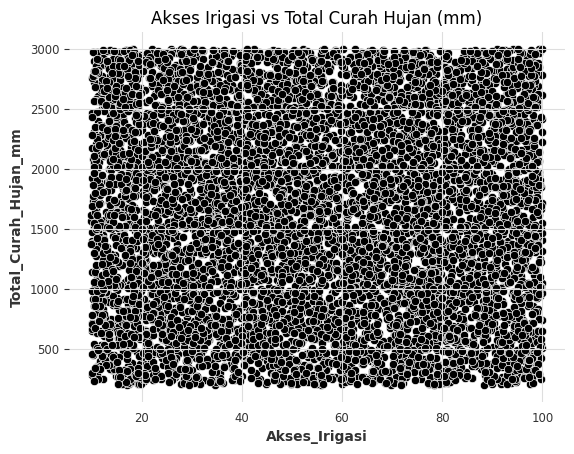

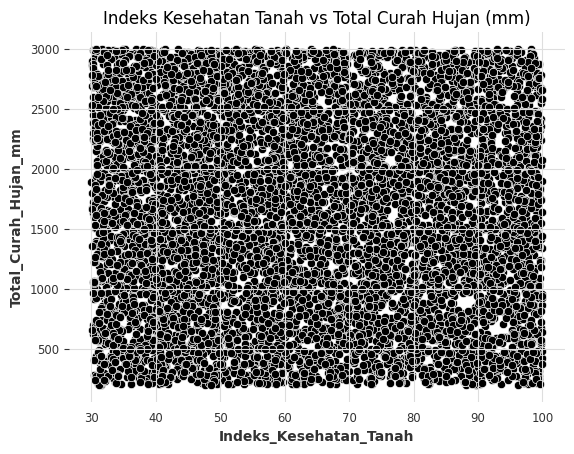

In [14]:
# pengecekan data-data tersebut melalui correlation
corr = df[['Total_Curah_Hujan_mm', 'Akses_Irigasi', 'Indeks_Kesehatan_Tanah']].corr()
display(corr)

sns.scatterplot(x='Akses_Irigasi', y='Total_Curah_Hujan_mm', data=df)
plt.title('Akses Irigasi vs Total Curah Hujan (mm)')
plt.show()

sns.scatterplot(x='Indeks_Kesehatan_Tanah', y='Total_Curah_Hujan_mm', data=df)
plt.title('Indeks Kesehatan Tanah vs Total Curah Hujan (mm)')
plt.show()

Berdasarkan pengamatan dari pendekatan korelasi linear, beberapa data tersebut tampak lemah karena antar data menunjukkan yang lebih mendekati dengan 0.

In [15]:
grouped = df.groupby('Wilayah')[['Total_Curah_Hujan_mm', 'Akses_Irigasi', 'Indeks_Kesehatan_Tanah']]
corr = grouped.corr()
unstacked = corr.unstack()
result = unstacked.iloc[:, 1] # type: ignore
result

,Total_Curah_Hujan_mm
,Akses_Irigasi
Wilayah,
'British Columbia',-0.064506
'Grand Est',-0.003511
'New South Wales',0.034151
'North Central',-0.002183
'North West',-0.048039
'Provence-Alpes-Cote d’Azur',-0.035954
'South East',-0.094108
'South West',-0.165426


In [16]:
features = ['Akses_Irigasi', 'Indeks_Kesehatan_Tanah', 'Hasil_Panen_Ton_per_HA', 'Penggunaan_Pupuk_KG_per_HA']
train_df = df[df['Total_Curah_Hujan_mm'].notnull()]
X = train_df[features]
y = train_df['Total_Curah_Hujan_mm']

rf = RandomForestRegressor(random_state=RANDOM_SEED)
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Mean R² score:", scores.mean())

Mean R² score: -0.06311072772969975


Karena hasil $R^2$ rendah yang menunjukkan bahwa antar data tersebut tidak menunjukkan korelasi yang signifikan. Untuk langkah selanjutnya maka bisa dilakukan proses data imputation sederhana melalui pengisian dengan metode **median**.

In [17]:
df['Total_Curah_Hujan_mm'] = df.groupby(['Wilayah', 'Tahun'])['Total_Curah_Hujan_mm'].transform(
    lambda x: x.fillna(x.median())
)

#### **Hasil_Panen_Ton_per_HA** Column

Diasumsikan bahwa kolom **Hasil_Panen_Ton_per_HA** berkolerasi dengan data kolom **Jenis_Tanaman**, **Kejadian_Cuaca_Ekstrim**, **Penggunaan_Pestisida_KG_per_HA**, **Penggunaan_Pupuk_KG_per_HA**, dan **Strategi_Adaptasi**.

In [18]:
features = ['Jenis_Tanaman', 'Kejadian_Cuaca_Ekstrim',
            'Penggunaan_Pestisida_KG_per_HA', 'Penggunaan_Pupuk_KG_per_HA',
            'Strategi_Adaptasi']

# Copy data
train_df = df[df['Hasil_Panen_Ton_per_HA'].notnull()].copy()
test_df = df[df['Hasil_Panen_Ton_per_HA'].isnull()].copy()

# Fill missing categorical values BEFORE encoding
train_df['Jenis_Tanaman'] = train_df['Jenis_Tanaman'].fillna(train_df['Jenis_Tanaman'].mode()[0])
train_df['Strategi_Adaptasi'] = train_df['Strategi_Adaptasi'].fillna(train_df['Strategi_Adaptasi'].mode()[0])

test_df['Jenis_Tanaman'] = test_df['Jenis_Tanaman'].fillna(train_df['Jenis_Tanaman'].mode()[0])
test_df['Strategi_Adaptasi'] = test_df['Strategi_Adaptasi'].fillna(train_df['Strategi_Adaptasi'].mode()[0])

# Encode categorical features AFTER filling missing values
le_jenis = LabelEncoder()
le_strategi = LabelEncoder()

train_df['Jenis_Tanaman'] = le_jenis.fit_transform(train_df['Jenis_Tanaman'].astype(str))
train_df['Strategi_Adaptasi'] = le_strategi.fit_transform(train_df['Strategi_Adaptasi'].astype(str))

test_df['Jenis_Tanaman'] = le_jenis.transform(test_df['Jenis_Tanaman'].astype(str))
test_df['Strategi_Adaptasi'] = le_strategi.transform(test_df['Strategi_Adaptasi'].astype(str))

# Prepare data
X_train = train_df[features]
y_train = train_df['Hasil_Panen_Ton_per_HA']
X_test = test_df[features]

# Handle missing NUMERIC values only (after encoding, all features are numeric)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Train model
rf = RandomForestRegressor(random_state=RANDOM_SEED)
rf.fit(X_train, y_train)

# Evaluate model performance
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("Mean R² score:", np.mean(scores))

Mean R² score: -0.078833803414697


Hasil $R^2$ tergolong rendah bahkan mencapai nilai di bawah 0. Ini menunjukkan bahwa antar data kurang berkolerasi satu sama lain. Maka dari itu, untuk langkah selanjutnya teknik yang digunakan adalah dengan menggunakan *median*.

In [19]:
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Jenis_Tanaman', 'Wilayah', 'Tahun'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# from the above method, it still show missing values
# Fallback 1: Jenis_Tanaman + Wilayah
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Jenis_Tanaman', 'Wilayah'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 2: Jenis_Tanaman + Tahun
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Jenis_Tanaman', 'Tahun'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 3: Wilayah + Tahun
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Wilayah', 'Tahun'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 4: Jenis_Tanaman only
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby('Jenis_Tanaman')['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 5: Wilayah only
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby('Wilayah')['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Final fallback: global median (guaranteed to fill everything)
df['Hasil_Panen_Ton_per_HA'] = df['Hasil_Panen_Ton_per_HA'].fillna(df['Hasil_Panen_Ton_per_HA'].median())

#### **Akses_Irigasi** Column

Data **Akses_Irigasi** ini diasumsikan memiliki korelasi dengan beberapa kolom berikut: *Total_Curah_Hujan_mm*, *Kejadian_Cuaca_Ekstrim*, *Nama_Negara*, *Wilayah*, *Tahun*, dan *Jenis_Tanaman*.

In [20]:
features = ['Total_Curah_Hujan_mm', 'Kejadian_Cuaca_Ekstrim',
            'Nama_Negara', 'Wilayah', 'Tahun', 'Jenis_Tanaman']

# Prepare data
train_df = df[df['Akses_Irigasi'].notnull()].copy()
test_df = df[df['Akses_Irigasi'].isnull()].copy()

# Encode categorical
le_country = LabelEncoder()
le_region = LabelEncoder()
le_crop = LabelEncoder()

train_df['Nama_Negara'] = le_country.fit_transform(train_df['Nama_Negara'])
train_df['Wilayah'] = le_region.fit_transform(train_df['Wilayah'])
train_df['Jenis_Tanaman'] = le_crop.fit_transform(train_df['Jenis_Tanaman'].astype(str))

test_df['Nama_Negara'] = le_country.transform(test_df['Nama_Negara'])
test_df['Wilayah'] = le_region.transform(test_df['Wilayah'])
test_df['Jenis_Tanaman'] = le_crop.transform(test_df['Jenis_Tanaman'].astype(str))

X_train = train_df[features]
y_train = train_df['Akses_Irigasi']
X_test = test_df[features]

# Handle missing numeric values
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Train model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Evaluate model
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("Mean R² score:", np.mean(scores))

Mean R² score: -0.0736050041516366


Hasil $R^2$ sangat rendah karena di bawah $0$. Maka dari itu data imputation bisa menggunakan *median*

In [21]:
df['Akses_Irigasi'] = (
    df.groupby(['Wilayah', 'Jenis_Tanaman'])['Akses_Irigasi']
      .transform(lambda x: x.fillna(x.median()))
)

### 2.4.2 Machine Learning Approach

#### **Jenis_Tanaman** Column

In [22]:
# features = ['Hasil_Panen_Ton_per_HA', 'Penggunaan_Pestisida_KG_per_HA',
#             'Penggunaan_Pupuk_KG_per_HA', 'Indeks_Kesehatan_Tanah']

# # Separate data
# train_df = df[df['Jenis_Tanaman'].notnull()]
# test_df = df[df['Jenis_Tanaman'].isnull()]

# # Encode Jenis_Tanaman
# le = LabelEncoder()
# y = le.fit_transform(train_df['Jenis_Tanaman'])

# # Impute missing numeric features if any
# imputer = SimpleImputer(strategy='median')
# X_train = imputer.fit_transform(train_df[features])
# X_test = imputer.transform(test_df[features])

# # Train classifier
# clf = RandomForestClassifier(random_state=42)
# clf.fit(X_train, y)

# # Predict
# preds = clf.predict(X_test)
# df.loc[df['Jenis_Tanaman'].isnull(), 'Jenis_Tanaman'] = le.inverse_transform(preds)

## 2.5 Hasil Data Imputation

In [23]:
print(f'Total data kosong: {df.isnull().values.sum()}')
display(df.isnull().sum())

Total data kosong: 217


,0
ID,0
Tahun,0
Nama_Negara,0
Wilayah,0
Jenis_Tanaman,8
Total_Curah_Hujan_mm,1
Emisi_CO2_JT_Ton,0
Hasil_Panen_Ton_per_HA,0
Kejadian_Cuaca_Ekstrim,0
Akses_Irigasi,8


In [24]:
# Check missing summary
display(df.isna().sum())

# See the actual rows
df_missing = df[df.isna().any(axis=1)]
display(df_missing[['Nama_Negara', 'Wilayah', 'Tahun', 'Jenis_Tanaman',
                  'Total_Curah_Hujan_mm', 'Akses_Irigasi']])

,0
ID,0
Tahun,0
Nama_Negara,0
Wilayah,0
Jenis_Tanaman,8
Total_Curah_Hujan_mm,1
Emisi_CO2_JT_Ton,0
Hasil_Panen_Ton_per_HA,0
Kejadian_Cuaca_Ekstrim,0
Akses_Irigasi,8


,Nama_Negara,Wilayah,Tahun,Jenis_Tanaman,Total_Curah_Hujan_mm,Akses_Irigasi
2112,Argentina,Patagonia,1990,Cotton,2132.01,59.64
6200,Argentina,Patagonia,1990,Soybeans,2455.56,10.60
792,Brazil,Northeast,1990,Corn,1684.51,26.68
7636,Brazil,South,1990,Rice,1741.26,66.27
7840,Russia,Central,1990,Rice,1103.53,95.71
...,...,...,...,...,...,...
6826,France,'Provence-Alpes-Cote d’Azur',2024,Rice,2894.15,59.90
2238,Nigeria,'South East',2024,Rice,1906.34,40.92
3317,Nigeria,'South West',2024,Soybeans,1181.35,61.16
1972,Russia,Siberian,2024,Cotton,1049.90,11.94


In [25]:
# last data imputation

df['Jenis_Tanaman'] = df.groupby('Wilayah')['Jenis_Tanaman'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

df['Total_Curah_Hujan_mm'] = df.groupby(['Wilayah', 'Tahun'])['Total_Curah_Hujan_mm']\
    .transform(lambda x: x.fillna(x.median()))
df['Total_Curah_Hujan_mm'] = df['Total_Curah_Hujan_mm'].fillna(df['Total_Curah_Hujan_mm'].median())

df['Akses_Irigasi'] = df.groupby(['Wilayah', 'Jenis_Tanaman'])['Akses_Irigasi']\
    .transform(lambda x: x.fillna(x.median()))
df['Akses_Irigasi'] = df['Akses_Irigasi'].fillna(df['Akses_Irigasi'].median())

display(df.isna().sum())

,0
ID,0
Tahun,0
Nama_Negara,0
Wilayah,0
Jenis_Tanaman,0
Total_Curah_Hujan_mm,0
Emisi_CO2_JT_Ton,0
Hasil_Panen_Ton_per_HA,0
Kejadian_Cuaca_Ekstrim,0
Akses_Irigasi,0


---

# 3. Exploratory Data Analysis (EDA)

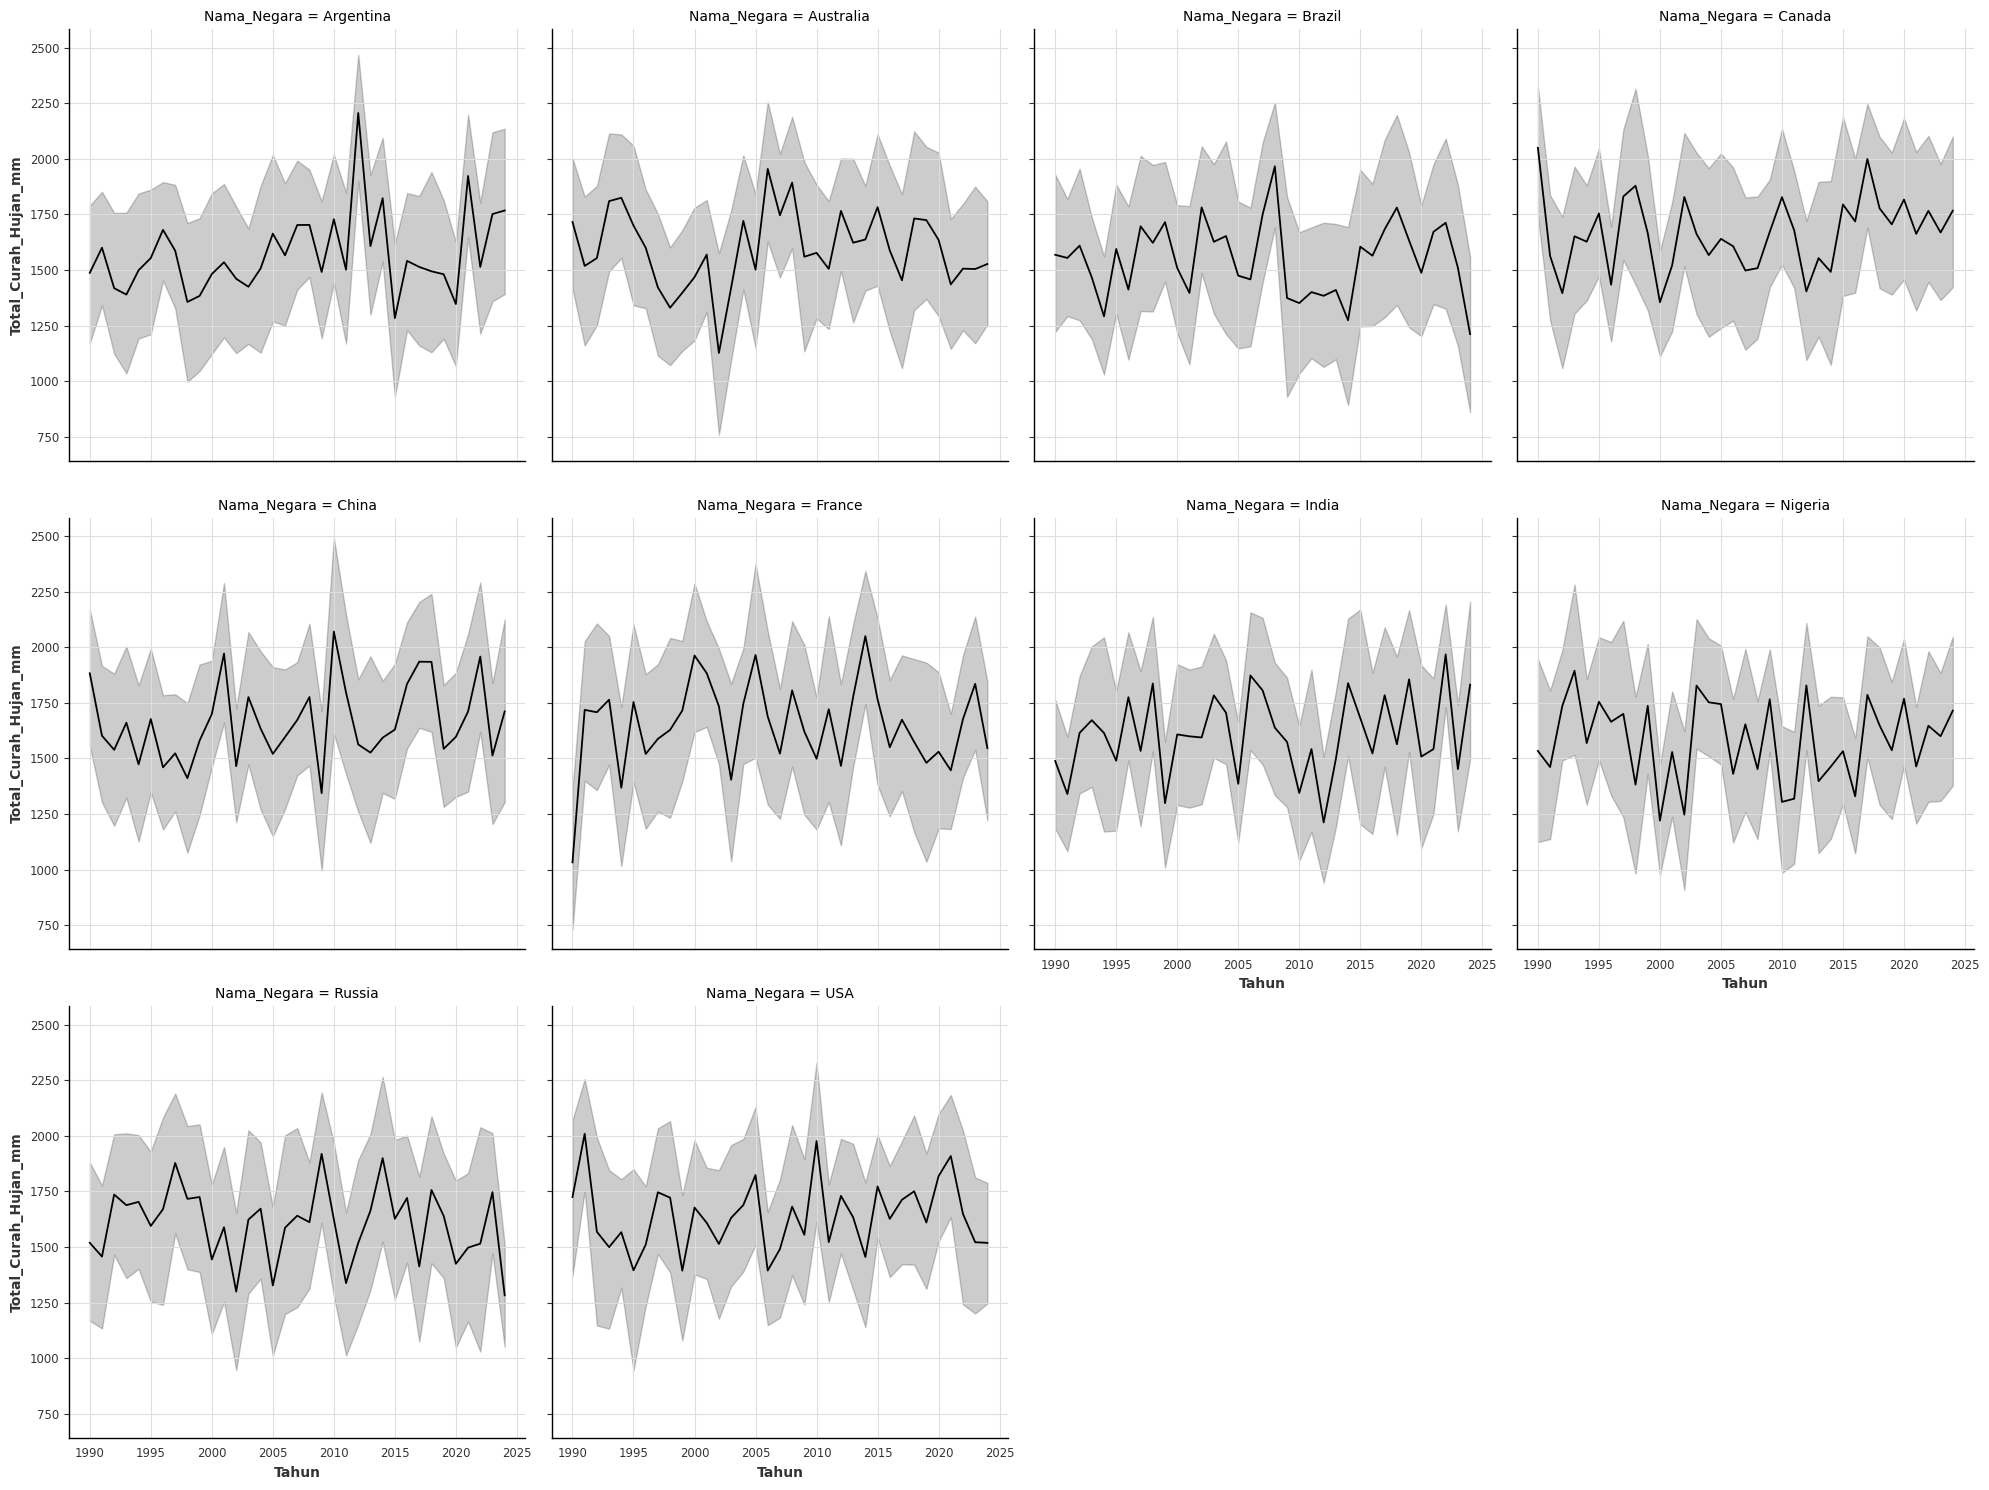

In [26]:
sns.relplot(
    data=df, x="Tahun", y="Total_Curah_Hujan_mm",
    col="Nama_Negara", kind="line",
    col_wrap=4,
)

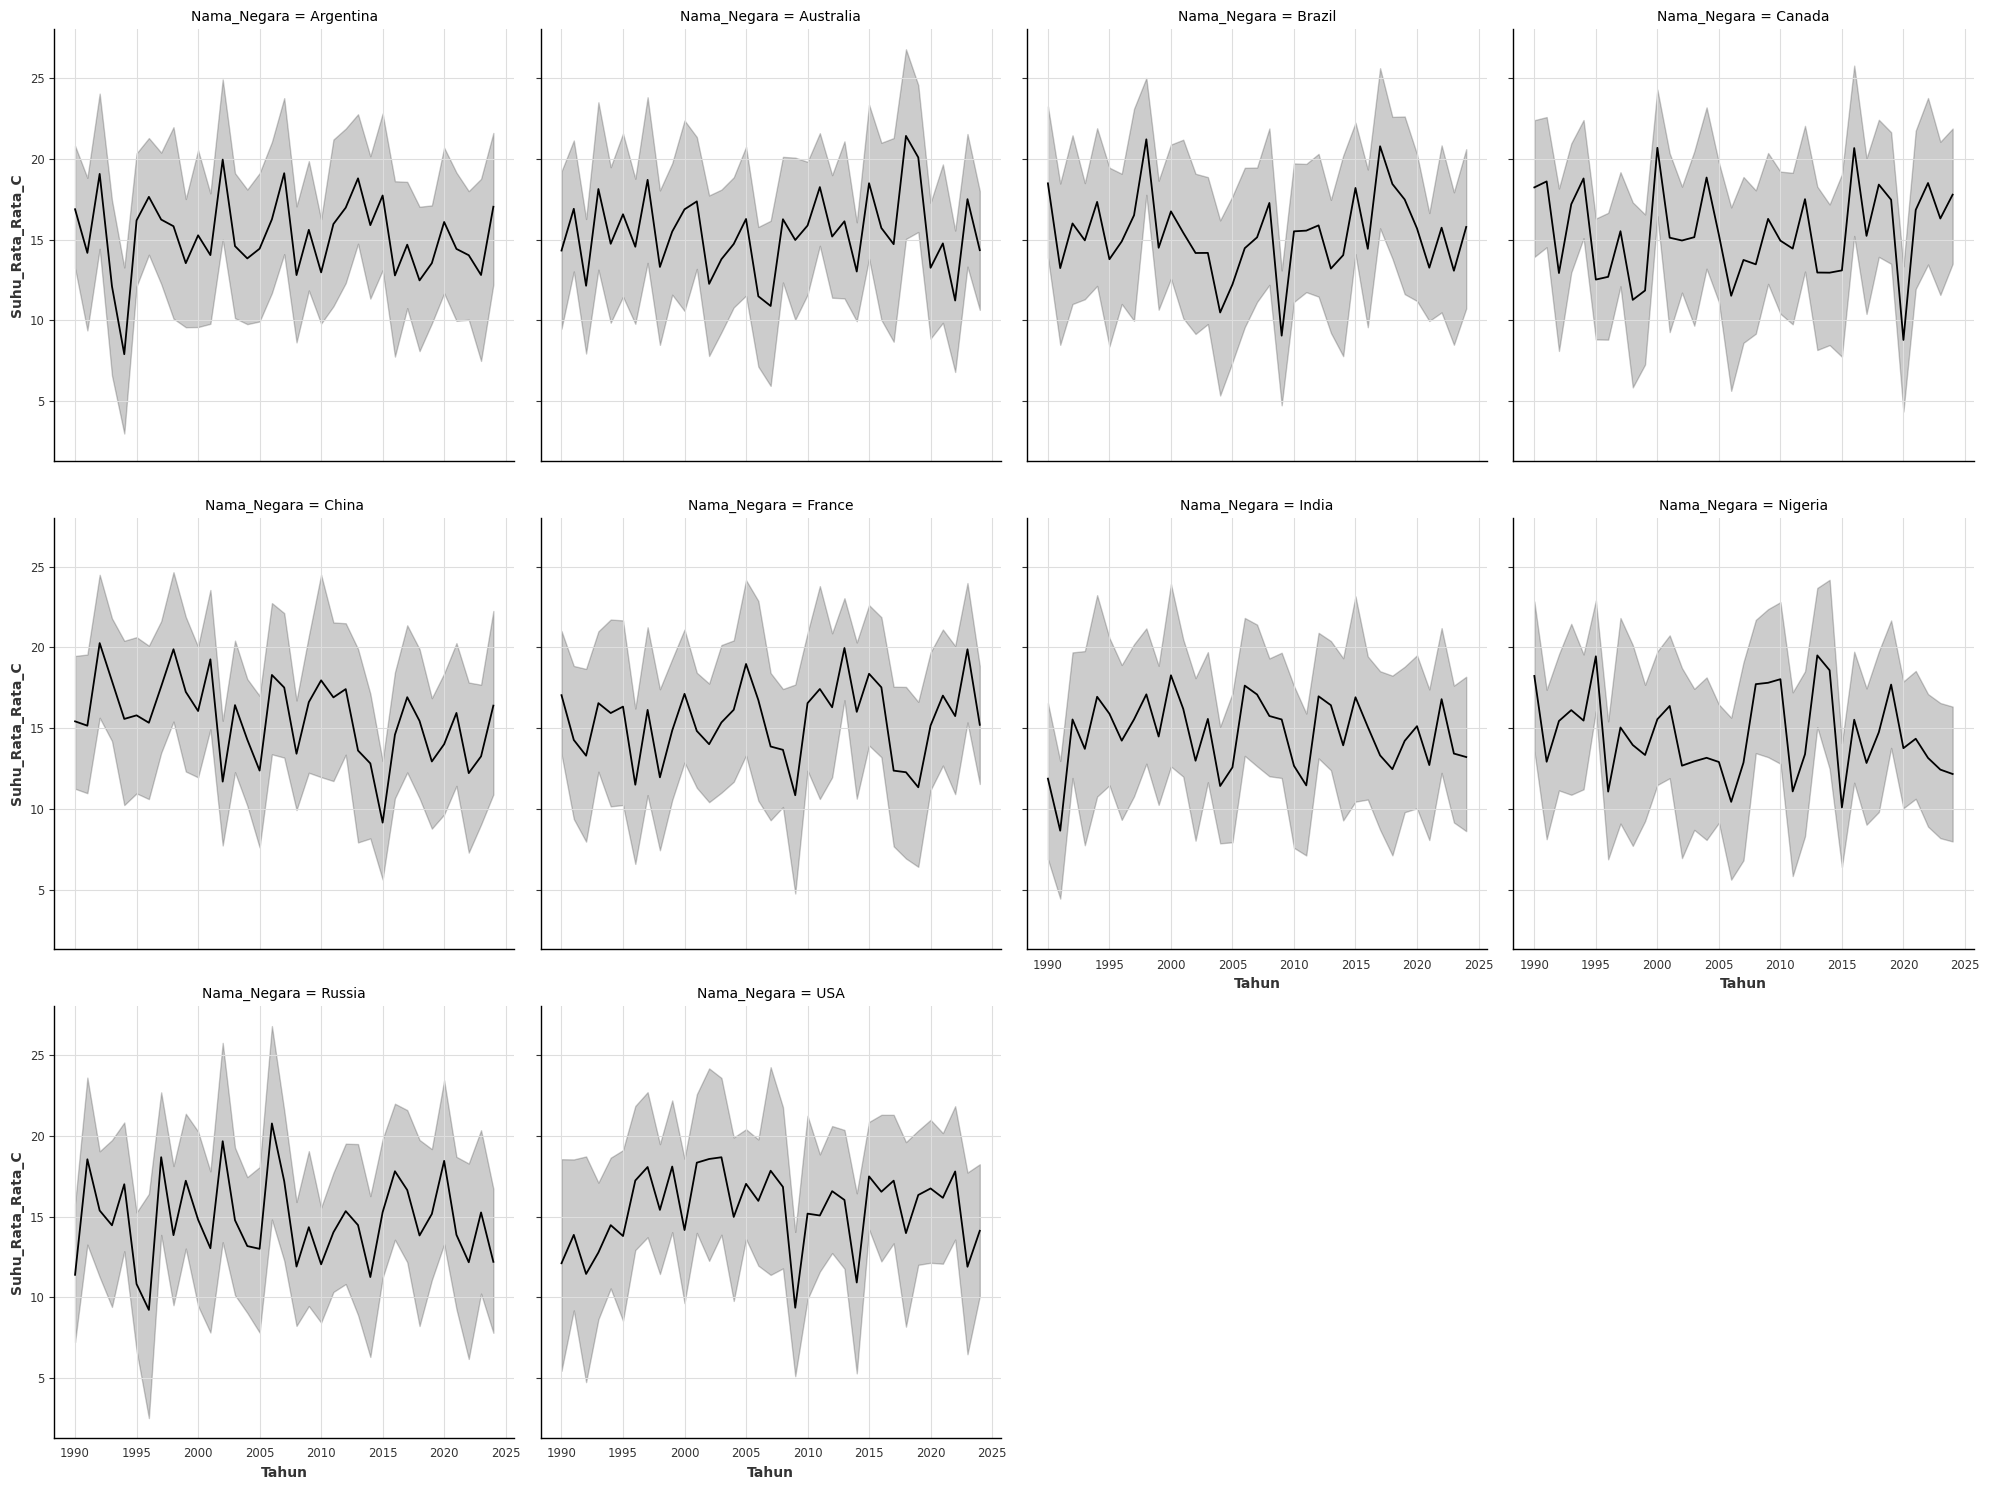

In [27]:
sns.relplot(
    data=df, x="Tahun", y="Suhu_Rata_Rata_C",
    col="Nama_Negara", kind="line",
    col_wrap=4,
)

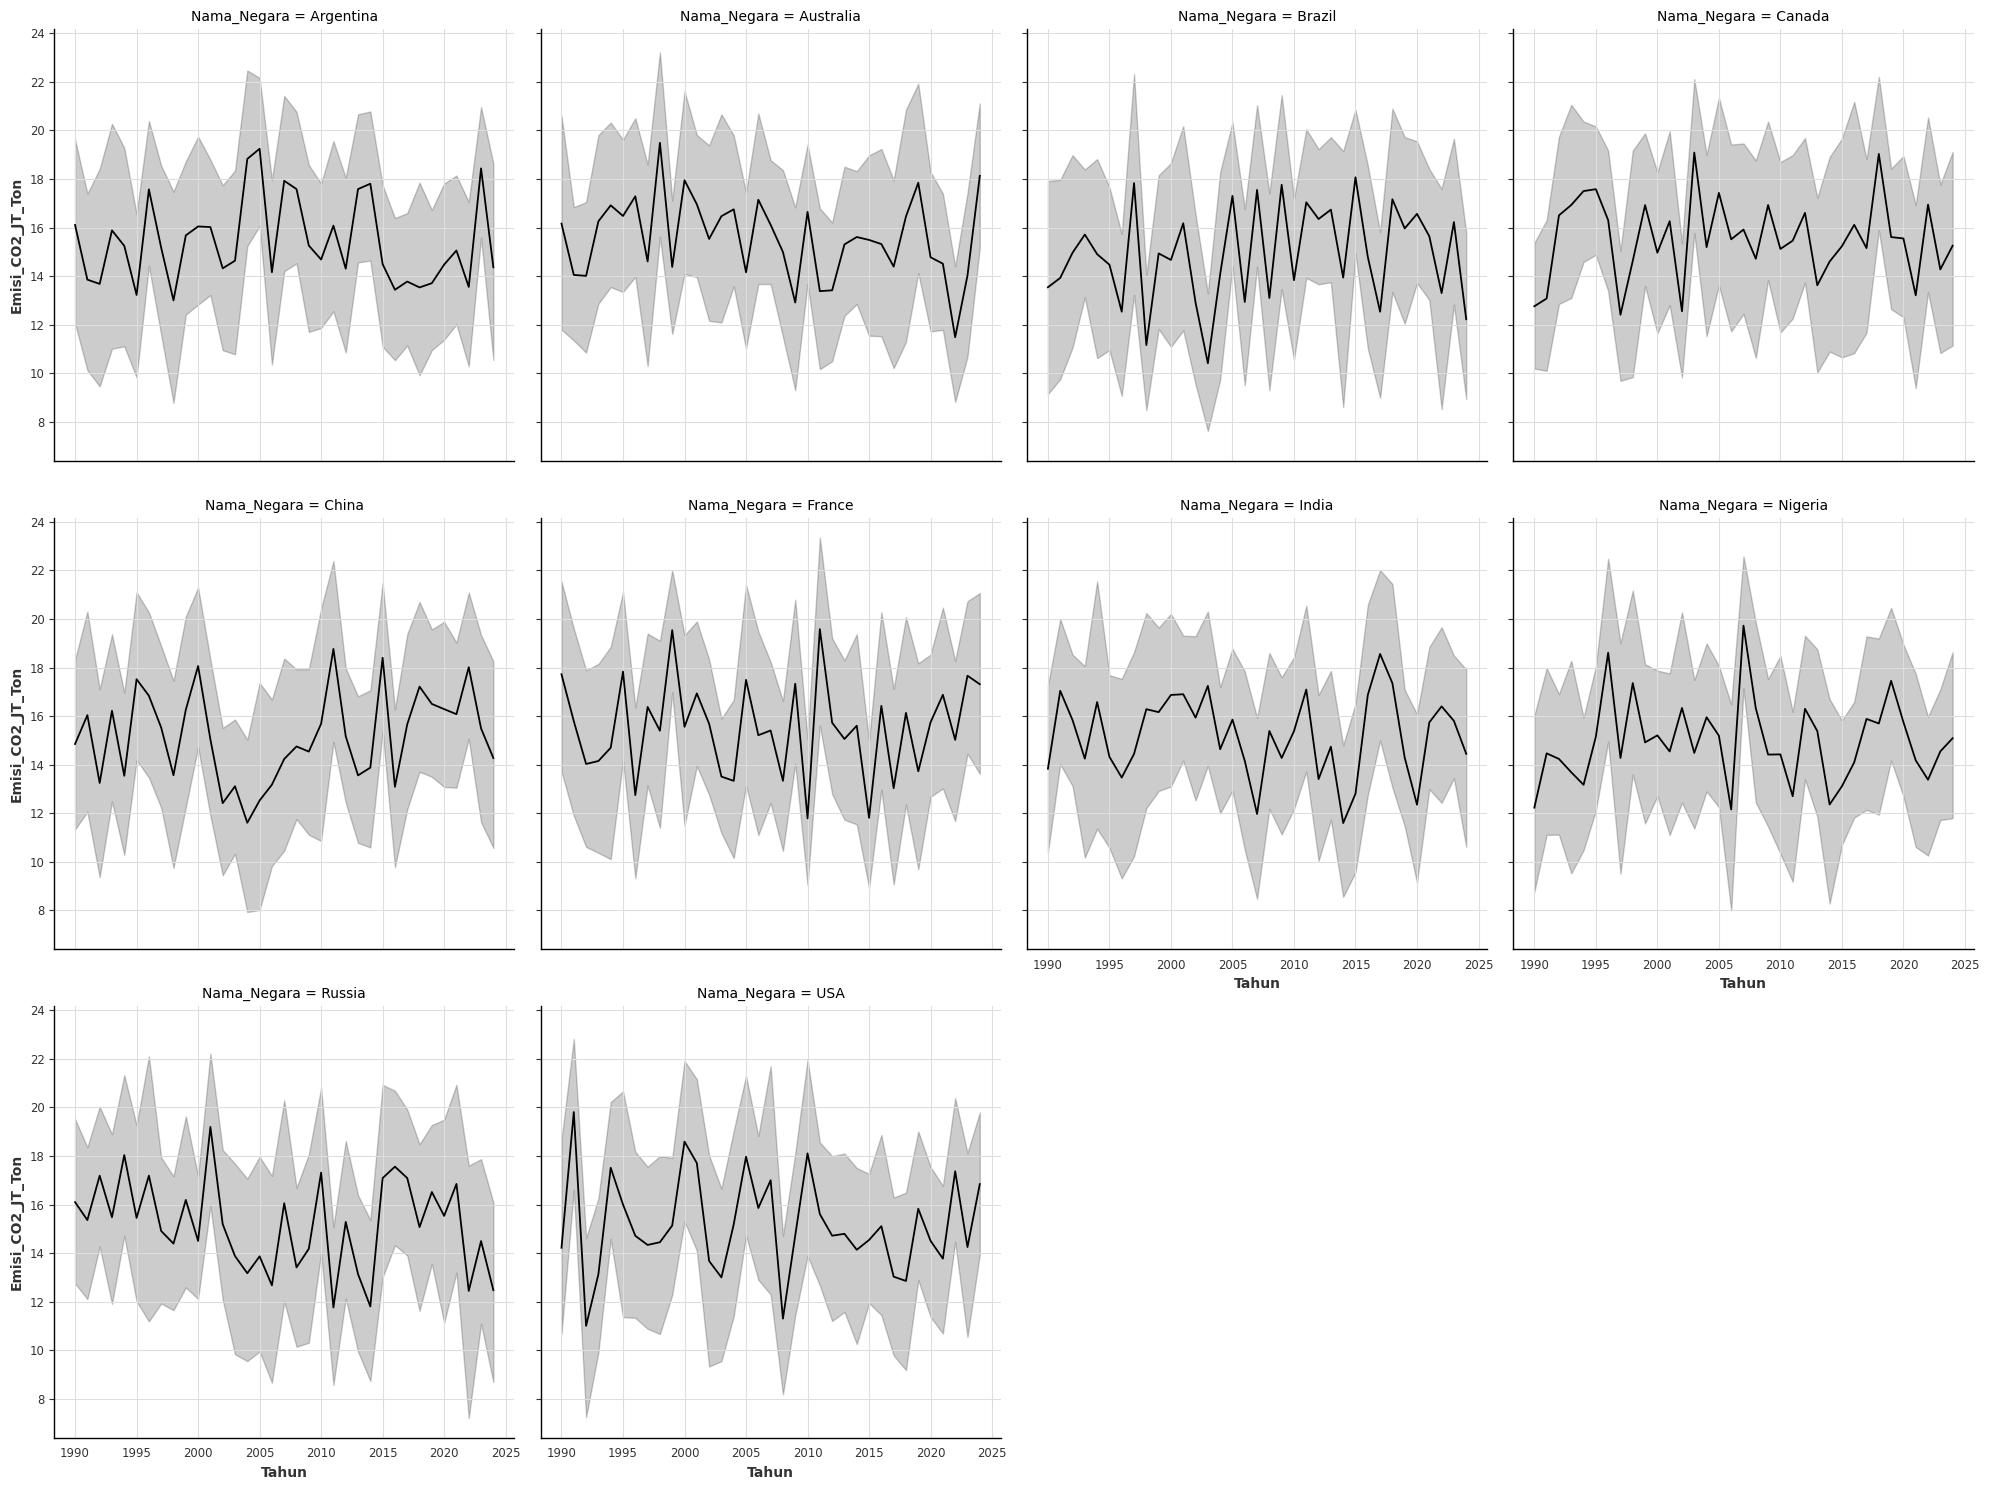

In [28]:
sns.relplot(
    data=df, x="Tahun", y="Emisi_CO2_JT_Ton",
    col="Nama_Negara", kind="line",
    col_wrap=4,
)

---

# 4. Feature Engineering & Selection

## 4.1 Feature Engineering


Data-data yang mungkin menjadi data fitur:
- Total_Curah_Hujan_mm
- Emisi_CO2_JT_Ton

In [29]:
print(f'Nama-nama negara: {df['Nama_Negara'].unique()}')
print(f'Wilayah-wilayah unik: ({df['Wilayah'].nunique()}) {df['Wilayah'].unique()}')

print(f'\nRentetan tahun: {df['Tahun'].unique()}')
print(f'\nJenis-jenis tanaman: {df['Jenis_Tanaman'].unique()}')
print(f'Strategi-strategi adaptasi: {df['Strategi_Adaptasi'].unique()}')

Nama-nama negara: ['Argentina' 'Australia' 'Brazil' 'Canada' 'China' 'France' 'India'
 'Nigeria' 'Russia' 'USA']
Wilayah-wilayah unik: (34) ['Northeast' 'Northwest' 'Pampas' 'Patagonia' "'New South Wales'"
 "'Western Australia'" 'Queensland' 'Victoria' 'North' 'South' 'Southeast'
 "'British Columbia'" 'Ontario' 'Prairies' 'Quebec' 'Central' 'East'
 "'Grand Est'" "'Provence-Alpes-Cote d’Azur'" 'Ile-de-France'
 'Nouvelle-Aquitaine' "'Tamil Nadu'" "'West Bengal'" 'Maharashtra'
 'Punjab' "'North Central'" "'North West'" "'South East'" "'South West'"
 'Northwestern' 'Siberian' 'Volga' 'Midwest' 'West']

Rentetan tahun: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024]

Jenis-jenis tanaman: ['Coffee' 'Corn' 'Cotton' 'Fruits' 'Rice' 'Sugarcane' 'Vegetables'
 'Soybeans' 'Barley' 'Wheat']
Strategi-strategi adaptasi: ['Tanpa Adaptasi' 'Manajemen Air' 'Rotasi Tanaman'
 

In [30]:
numeric_features = ['Total_Curah_Hujan_mm', 'Hasil_Panen_Ton_per_HA', 'Akses_Irigasi']
categorical_features = ['Jenis_Tanaman', 'Nama_Negara', 'Wilayah', 'Strategi_Adaptasi']

# 5. MAIN PROCESSING

In [31]:
categorical_features = ['Jenis_Tanaman', 'Nama_Negara', 'Wilayah', 'Strategi_Adaptasi']
target_col = 'Suhu_Rata_Rata_C'
exclude_cols = ['ID', target_col, 'Strategi_Adaptasi', 'Pupuk_bin', 'Pestisida_bin', 'Hasil_bin']

print(f'Exclude columns: {exclude_cols}')

# Drop excluded columns (errors='ignore' is fine)
X = df.drop(columns=exclude_cols, errors='ignore')
y = df[target_col]

# Keep only categorical columns that actually exist in X
present_cats = [c for c in categorical_features if c in X.columns]
missing_cats = [c for c in categorical_features if c not in X.columns]

if missing_cats:
    print(f"⚠️ These categorical columns are missing from X and will be ignored: {missing_cats}")

# Numeric (non-categorical) columns in X
numeric_features = [col for col in X.columns if col not in present_cats]

# If there are categorical columns, build a ColumnTransformer; otherwise just use X as-is
if present_cats:
    encoder = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            # sparse_output=False -> get dense array so we can build DataFrame easily (scikit-learn >=1.2)
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), present_cats)
        ],
        remainder='drop'
    )
    X_encoded = encoder.fit_transform(X)

    # get cat feature names (only available if 'cat' exists)
    cat_feature_names = encoder.named_transformers_['cat'].get_feature_names_out(present_cats)
    feature_cols = list(numeric_features) + list(cat_feature_names)
else:
    # no categorical columns available -> no encoding needed
    X_encoded = X.copy().to_numpy()
    feature_cols = list(X.columns)

# Build DataFrame
df_encoded = pd.DataFrame(X_encoded, columns=feature_cols, index=X.index)
df_encoded[target_col] = y

print(f"✅ Preprocessing done: used categorical columns {present_cats} → {len(feature_cols)} total features")

Exclude columns: ['ID', 'Suhu_Rata_Rata_C', 'Strategi_Adaptasi', 'Pupuk_bin', 'Pestisida_bin', 'Hasil_bin']
⚠️ These categorical columns are missing from X and will be ignored: ['Strategi_Adaptasi']
✅ Preprocessing done: used categorical columns ['Jenis_Tanaman', 'Nama_Negara', 'Wilayah'] → 60 total features


In [32]:
# Create time index
df_encoded['t'] = np.arange(len(df_encoded))

# Create Darts series for target and covariates
series_target = TimeSeries.from_dataframe(df_encoded, time_col='t', value_cols=[target_col])
series_cov = TimeSeries.from_dataframe(df_encoded, time_col='t', value_cols=feature_cols)

# Scale both
scaler_y, scaler_x = Scaler(), Scaler()
series_target_s = scaler_y.fit_transform(series_target)
series_cov_s = scaler_x.fit_transform(series_cov)

# Temporal split (80/20)
split_idx = int(len(df_encoded) * 0.8)
split_point = series_target_s.time_index[split_idx]

# Split BEFORE converting to DataFrames
series_trg_train, series_trg_val = series_target_s.split_before(split_point)
series_cov_train, series_cov_val = series_cov_s.split_before(split_point)

# Convert to DataFrames with continuous index starting from 0
df_train = pd.DataFrame(series_cov_train.values(copy=False))
df_val   = pd.DataFrame(series_cov_val.values(copy=False))

df_train.index = range(len(df_train))
df_val.index   = range(len(df_train), len(df_train) + len(df_val))

df_full = pd.concat([df_train, df_val])

# Rebuild TimeSeries with proper continuous time index
series_cov_full = TimeSeries.from_dataframe(df_full)

# CRITICAL: Rebuild target series with matching time index
df_target_full = pd.DataFrame(series_target_s.values(copy=False), columns=[target_col])
df_target_full.index = df_full.index
series_target_full = TimeSeries.from_dataframe(df_target_full)

# Re-split with consistent indexing
series_trg_train = series_target_full[:len(df_train)]
series_trg_val = series_target_full[len(df_train):]
series_cov_train = series_cov_full[:len(df_train)]
series_cov_val = series_cov_full[len(df_train):]

print("✅ Combined covariates created successfully!")
print("start:", series_cov_full.start_time(), "end:", series_cov_full.end_time())
print("total rows:", len(series_cov_full))

print(f"📊 Train length: {len(series_trg_train)} | Validation length: {len(series_trg_val)}")

✅ Combined covariates created successfully!
start: 0 end: 7999
total rows: 8000
📊 Train length: 6400 | Validation length: 1600


In [33]:
x = df_encoded[target_col].values
x = x - np.mean(x)
max_k = min(48, max(3, len(x)//2))
best_k, best_corr = 1, 0.0

for k in range(2, max_k + 1):
    corr = np.corrcoef(x[:-k], x[k:])[0, 1]
    if np.isfinite(corr) and corr > best_corr:
        best_corr, best_k = corr, k

K_guess = best_k if best_corr >= 0.3 else 1
print(f"🔎 Inferred seasonality: K = {K_guess} (corr={best_corr:.2f})")

# You can override manually if needed
K_guess = 12

🔎 Inferred seasonality: K = 1 (corr=0.02)


In [34]:
lgbm_lags = max(12, int(K_guess))

base_models = [
    LightGBMModel(lags=lgbm_lags * 2, lags_past_covariates=lgbm_lags, output_chunk_length=1, random_state=RANDOM_SEED),
    XGBModel(lags=lgbm_lags * 2, lags_past_covariates=lgbm_lags, output_chunk_length=1, random_state=RANDOM_SEED),
    NaiveDrift(),
    NaiveSeasonal(K=max(2, int(K_guess)))
]

model_ts = RegressionEnsembleModel(
    forecasting_models=base_models,
    regression_train_n_points=max(12, int(min(48, K_guess))),
)

model_ts.fit(
    series_trg_train,
    past_covariates=series_cov_train,
)

print("✅ Model training completed!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29232
[LightGBM] [Info] Number of data points in the train set: 6364, number of used features: 744
[LightGBM] [Info] Start training from score 0.506471


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016467 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29234
[LightGBM] [Info] Number of data points in the train set: 6376, number of used features: 744
[LightGBM] [Info] Start training from score 0.506399
✅ Model training completed!


# 7. Validation Prediction & Evaluation

In [35]:
# Predict and inverse transform
pred_val_s = model_ts.predict(len(series_trg_val), past_covariates=series_cov_full)
pred_val = scaler_y.inverse_transform(pred_val_s)
true_val = scaler_y.inverse_transform(series_trg_val)

# Compute metrics
val_mape = mean_absolute_percentage_error(true_val, pred_val)
val_rmse = root_mean_squared_error(true_val, pred_val)

print(f"📈 Validation Results → MAPE: {val_mape:.3f} | RMSE: {val_rmse:.3f}")

Streaming output truncated to the last 5000 lines.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERROR:darts.timeseries:IndexError: Integer index out of range.
ERRO

In [ ]:
plt.figure(figsize=(10,5))
true_val.plot(label="Actual", lw=2)
pred_val.plot(label="Predicted", lw=2)
plt.legend()
plt.title("Actual vs Predicted (Validation)")
plt.show()

# 8. Generate Predictions

In [ ]:
# Load test data
df_test = pd.read_csv(paths['test_csv'])

# Apply same preprocessing
df_test[numeric_features] = numeric_imputer.transform(df_test[numeric_features])
df_test[categorical_features] = cat_imputer.transform(df_test[categorical_features])

for col in categorical_features:
    df_test[f'{col}_encoded'] = label_encoders[col].transform(df_test[col])

# Feature engineering on test
df_test['CO2_per_Rainfall'] = df_test['Emisi_CO2_JT_Ton'] / (df_test['Total_Curah_Hujan_mm'] + 1)
df_test['Pesticide_per_Fertilizer'] = df_test['Penggunaan_Pestisida_KG_per_HA'] / (df_test['Penggunaan_Pupuk_KG_per_HA'] + 1)
df_test['Yield_Efficiency'] = df_test['Hasil_Panen_Ton_per_HA'] * df_test['Indeks_Kesehatan_Tanah'] / 100

X_test = df_test[feature_cols]
X_test_scaled = scaler.transform(X_test)  # kept in case you also run the sklearn path

# --- Darts prediction path ---
# Build a future time index for test and extend covariates into the future so models with lags_past_covariates can predict autoregressively
try:
    # Ensure we have the training _df_ts and covariate/Scaler objects from the Darts section
    if '_df_ts' not in globals() and '_df_ts' not in locals():
        raise RuntimeError("Darts training variables not found. Run the Darts training cell first.")
    if 'scaler_x' not in globals() and 'scaler_x' not in locals():
        raise RuntimeError("Darts scalers not found. Run the Darts training cell first.")

    # Create future time index continuing after the last training step
    df_test_ts = df_test.copy()
    start_t = int(_df_ts['t'].iloc[-1]) + 1 if 't' in _df_ts.columns else len(_df_ts)
    df_test_ts['t'] = np.arange(start_t, start_t + len(df_test))

    # Build future covariates TimeSeries and append to training covariates, then scale consistently
    covar_cols = [c for c in feature_cols if c != 'Suhu_Rata_Rata_C']
    series_cov_future = TimeSeries.from_dataframe(df_test_ts[['t'] + covar_cols], time_col='t', value_cols=covar_cols)
    series_cov_full = series_cov.append(series_cov_future)
    series_cov_full_s = scaler_x.transform(series_cov_full)

    # Predict n steps equal to test length using the SAME training target series used at fit to ensure aligned time axis
    n_test = len(df_test)
    pred_test_s = model_ts.predict(n_test, series=series_trg_train, past_covariates=series_cov_full_s)
    pred_test = scaler_y.inverse_transform(pred_test_s)
    predictions = pred_test.values().reshape(-1)

    # Optional sanity clamp to plausible physical range based on train stats
    y_min, y_max = df['Suhu_Rata_Rata_C'].quantile(0.01), df['Suhu_Rata_Rata_C'].quantile(0.99)
    predictions = np.clip(predictions, y_min - 1.0, y_max + 1.0)
except Exception as e:
    # Fallback or explicit error to guide the user
    raise RuntimeError(f"Failed to generate Darts predictions. Ensure the Darts training cell ran successfully. Details: {e}")

# Save submission
submission = pd.DataFrame({
    'ID': df_test['ID'],
    'Suhu_Rata_Rata_C': predictions
})
submission_path = f"{paths['save_dir']}/submission_xgb.csv"
submission.to_csv(submission_path, index=False)
print(f"✅ Submission saved to {submission_path}")